# Modelo híbrido CNN (NDVI) + tabular — ChicharritAI

Extensión del modelo de **riesgo a la siguiente lectura (~14 días)** que fusiona un parche **NDVI (Sentinel-2)** procesado por una CNN con las **mismas features tabulares** que el pipeline del notebook `03_modelo_14d.ipynb`.

## Arquitectura híbrida

```
NDVI (64×64) → CNN → embedding 32d ────────┐
                                            ├─ concat → cabeza de fusión → P(outbreak)
Features tabulares → MLP → embedding 32d ──┘
```

**Contraste principal**: En `03_modelo_14d.ipynb`, la sección **12 (MLP baseline)** entrena la rama tabular + cabeza de fusión **sin** CNN ni satélite. Este cuaderno añade la rama NDVI y compara métricas en el **mismo test temporal** (2025-2026).

**Hipótesis**: el estado de la vegetación alrededor de la trampa complementa clima y monitoreo para *Dalbulus maidis*.

**NDVI**: los parches se guardan en `cache/ndvi/*.npy`. Si **ya tenés todos** los archivos para tus pares, el bucle de §2 **solo hace `np.load`** (rápido, sin internet ni credenciales). Solo hace falta Copernicus (`SH_CLIENT_ID` / `SH_CLIENT_SECRET`) o NDVI **sintético** cuando falta un `.npy` en caché.

**Split temporal**: train 2024-2025, test 2025-2026 (igual que 03).

---

## Cómo ejecutar

| Orden | Qué hacer |
|-------|-----------|
| 1 | Tener `cache/geocoding.json` y, para tabulares alineados, `output/dataset_14d.csv` (generado con `03_modelo_14d.ipynb`). |
| 2 | Opcional: credenciales Copernicus **solo** si te faltan `.npy` en `cache/ndvi/`; con caché completa no hace falta. |
| 3 | Ejecutar secciones en orden: **1 → 2 → 3** (EDA NDVI) → **3.5** (merge tabular) → **4–6** (entrenar híbrido) → **7** (tabla y curvas vs MLP y XGBoost). |

Para comparar con el **MLP sin satélite**, entrenar antes la sección **12** de `03_modelo_14d.ipynb` y dejar `output/mlp_baseline_best.pt` en el proyecto.

**¿Solo querés cargar NDVI y tabular sin regenerar?** → leé la celda markdown siguiente (**Receta A / B**): ahí está el paso a paso con números de sección.

---

## Qué celdas **generan** datos vs **cargan** archivos

| Sección | Rol | Qué hace |
|---------|-----|----------|
| **Setup** (imports) | Carga librerías | No genera dataset. |
| **Atajo bundle** (celda siguiente al setup) | **Carga** | Si `USAR_BUNDLE_GUARDADO=True` y existen archivos en `output/hybrid_14d_ready/`, arma `df`, `ndvi_array`, `X_tabular`, `y`, máscaras. **Saltás §1–3.5.** |
| **§1** | **Genera** | Lee `csvs/*.csv` + `cache/geocoding.json` → construye `df` (pares) y `pairs`. |
| **§2** (config SH + funciones + bucle) | **Genera / cache** | Parches en `cache/ndvi/*.npy`. Si ya están todos, el bucle es **solo lectura** (no red). Si falta alguno, descarga o sintético. |
| **§3** | Solo gráficos | Necesita `ndvi_patches` / `ndvi_array` ya creados. |
| **§3.5** | **Carga + genera** | **Carga** `output/dataset_14d.csv` (del notebook 03) y **merge** con `df` → `X_tabular`, `ndvi_array` alineado. |

### Camino rápido (sin regenerar pares ni NDVI)

1. Ejecutá **solo** la celda de **setup** (imports).
2. En la celda **Atajo — bundle**, poné `USAR_BUNDLE_GUARDADO = True` y ejecutala (el bundle se crea **solo** la primera vez al ejecutar **§3.5**: al final de esa celda se guarda en `output/hybrid_14d_ready/` automáticamente).
3. **No ejecutes** las celdas de las secciones **1, 2, 3 ni 3.5** (si lo hacés con bundle activo, la notebook te avisa con un error claro).
4. Continuá desde la **§4** (definición del modelo híbrido).

### Solo tabular desde 03 (sin atajo completo)

Si no tenés bundle pero sí **`output/dataset_14d.csv`**, igual tenés que ejecutar **§1** (pares) y **§2** (NDVI, o confiar en `cache/ndvi/` ya lleno) antes del **merge** en **§3.5**.


In [1]:
import json, os, re, warnings, time
from IPython.display import display
from datetime import datetime, timedelta
from pathlib import Path
from math import radians, sin, cos, sqrt, atan2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    roc_auc_score, roc_curve, classification_report,
    confusion_matrix, precision_recall_curve, average_precision_score, f1_score,
)
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', font_scale=1.1)
TARGET_COLORS = {0: '#2ecc71', 1: '#e74c3c'}

DEVICE = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)
print(f'Device: {DEVICE}')

# Config
NDVI_PATCH_SIZE = 64   # pixels (64x64 at 10m = 640m x 640m)
NDVI_RESOLUTION = 10   # meters per pixel
NDVI_CACHE_DIR = Path('cache/ndvi')
NDVI_CACHE_DIR.mkdir(parents=True, exist_ok=True)

CAPTURE_THRESHOLD = 5
print('Setup completo.')

Device: mps
Setup completo.


### Solo cargar NDVI + tabular (tener `X_tabular` y `ndvi_array` listos)

En este notebook **no hay dos celdas separadas** “una para NDVI y otra para tabular”: el tabular remoto viene de `output/dataset_14d.csv` y se **une** a los pares en §3.5. Elegí **una** de estas recetas:

---

#### Receta A — Todo ya guardado (recomendado si repetís experimentos)

**Archivos:** `output/hybrid_14d_ready/df.parquet`, `ndvi_array.npy`, `feature_cols.json` (se crean **solos** al ejecutar la celda de **§3.5** merge; `GUARDAR_BUNDLE_TRAS_MERGE=True` por defecto).

**Celdas a ejecutar:**

1. **Setup** (imports, `NDVI_CACHE_DIR`, etc.).
2. Celda **Atajo — bundle**: poné `USAR_BUNDLE_GUARDADO = True` y ejecutala.

Listo: tenés `df`, `X_tabular`, `ndvi_array`, `y`, máscaras. **No ejecutes** §1, §2, §3 ni §3.5.

---

#### Receta B — Sin bundle: leer caché NDVI + CSV tabular del 03

**Archivos previos:** `cache/geocoding.json`, `output/dataset_14d.csv` (del `03_modelo_14d.ipynb`), y idealmente `cache/ndvi/*.npy` ya generados (si no, el bucle puede tardar o usar sintético).

**Celdas en orden:**

1. **Setup**
2. Celda **Atajo**: dejá `USAR_BUNDLE_GUARDADO = False` (o no la ejecutes).
3. **§1** (una celda de código): arma `df` / `pairs` desde `csvs/` — hace falta para alinear claves con el CSV.
4. **§2** — tres celdas seguidas: configuración Sentinel, funciones NDVI, **bucle de parches**. Con **`cache/ndvi/` ya completo** para tu `df`, el bucle **solo lee** `.npy` (sin Copernicus ni red). La primera celda del bucle imprime `n_cached / n_total`.
5. **§3.5** (celda de merge): **aquí se carga el tabular** con `pd.read_csv('output/dataset_14d.csv', ...)` y se fusiona con `df`.

Opcional: **§3** solo si querés gráficos exploratorios.

---

#### Dónde vive cada dato

| Dato | Archivo en disco | Momento en que entra |
|------|------------------|------------------------|
| Features tabulares (clima, vecinos, etc.) | `output/dataset_14d.csv` | Celda §3.5 (`read_csv`) |
| Parches NDVI | `cache/ndvi/<lat>_<lon>_<fechas>.npy` | Celda §2 (bucle); si no existe, intenta API o sintético |
| Todo junto ya alineado | `output/hybrid_14d_ready/*` | Celda **Atajo** con `USAR_BUNDLE_GUARDADO=True` |

**Resumen:** para *solo* cargar sin recomputar, usá **Receta A** si tenés el bundle; si no, **Receta B** y confiá en que §2 sea rápida porque los `.npy` ya están en `cache/ndvi/`.

In [3]:
# =============================================================================
# ATAJO — Carga única de NDVI + tabular ya alineados (Receta A del markdown de arriba)
# =============================================================================
# Qué hace: lee df.parquet + ndvi_array.npy + feature_cols.json → mismo resultado
# que haber corrido §1 + §2 + §3.5, sin ejecutar esas secciones.
#
# Cómo obtener esos archivos la primera vez: en la celda §3.5 (merge), descomentá
# "Guardar bundle", ejecutá, y quedan en output/hybrid_14d_ready/
#
# Si USAR_BUNDLE_GUARDADO=False: no pasa nada; seguí con Receta B (§1 → §2 → §3.5).

USAR_BUNDLE_GUARDADO = False  # True solo si ya corriste §3.5 y existe output/hybrid_14d_ready/

_BUNDLE_ROOT = Path('output/hybrid_14d_ready')
_BUNDLE_DF = _BUNDLE_ROOT / 'df.parquet'
_BUNDLE_NDVI = _BUNDLE_ROOT / 'ndvi_array.npy'
_BUNDLE_FEATS = _BUNDLE_ROOT / 'feature_cols.json'

HYBRID_FROM_BUNDLE = False
if USAR_BUNDLE_GUARDADO and _BUNDLE_DF.is_file() and _BUNDLE_NDVI.is_file() and _BUNDLE_FEATS.is_file():
    HYBRID_FROM_BUNDLE = True
    feature_cols = json.loads(_BUNDLE_FEATS.read_text(encoding='utf-8'))
    df = pd.read_parquet(_BUNDLE_DF)
    ndvi_array = np.load(_BUNDLE_NDVI)
    y = df['target']
    train_mask = df['temporada'] == '2024-2025'
    test_mask = df['temporada'] == '2025-2026'
    X_tabular = df[feature_cols]
    ndvi_patches = list(ndvi_array)
    print(f'Bundle OK: {_BUNDLE_ROOT} | filas={len(df)} | NDVI={ndvi_array.shape}')
elif USAR_BUNDLE_GUARDADO:
    print(
        'Todavía no existe el bundle (primera vez o borraste la carpeta).\n\n'
        'Hacé esto una vez:\n'
        '  1) En esta celda poné USAR_BUNDLE_GUARDADO = False y ejecutala.\n'
        '  2) Ejecutá §1 → §2 (tres celdas) → §3.5 (merge). '
        'Al final de §3.5 se guarda solo en output/hybrid_14d_ready/.\n'
        '  3) Volvé acá y poné USAR_BUNDLE_GUARDADO = True.\n\n'
        f'Ruta esperada: {_BUNDLE_ROOT.resolve()}'
    )
else:
    print('Atajo desactivado (USAR_BUNDLE_GUARDADO=False). Ejecutá §1 → §2 → §3.5 como siempre.')

Atajo desactivado (USAR_BUNDLE_GUARDADO=False). Ejecutá §1 → §2 → §3.5 como siempre.


## 1. Carga de datos crudos y construcción de pares

Cargamos directamente los CSVs de monitoreo y el cache de geocodificación para obtener las **coordenadas y fechas** de cada par (lectura actual → siguiente).

Esto nos da todo lo necesario para buscar NDVI de Sentinel-2 **sin depender** de que se hayan computado las features tabulares avanzadas (espaciales, climáticas, etc.), que se calculan después.

In [4]:
if globals().get('HYBRID_FROM_BUNDLE'):
    raise RuntimeError(
        'Ya cargaste el bundle en la celda de atajo: no ejecutes la §1. '
        'Seguí desde la §4 (modelo híbrido).'
    )

# === 1.1 Cargar lecturas crudas desde CSVs ===

CSVS_DIR = "csvs"
N_REPORTS = 38
ENDEMIC_LAT, ENDEMIC_LON = -26.8, -65.2

REPORT_SEASON_MAP = {i: "2024-2025" for i in range(1, 22)}
REPORT_SEASON_MAP.update({i: "2025-2026" for i in range(22, 39)})
NON_READING_COLS = {"zona", "región", "region", "provincia", "provincia/pais",
                    "localidad", "latitud", "longitud"}
LOCALIDAD_REPLACEMENTS = {"gral.": "general", "gral ": "general ",
                          "nstra": "nuestra"}

def parse_date_range(col_name):
    match = re.search(r"(\d{2}_\d{2}_\d{2})_al_(\d{2}_\d{2}_\d{2})", col_name)
    if not match:
        raise ValueError(f"No se pudo parsear fecha: {col_name}")
    return (datetime.strptime(match.group(1), "%d_%m_%y"),
            datetime.strptime(match.group(2), "%d_%m_%y"))

def normalize_localidad(name):
    s = name.strip().lower()
    for abbr, full in LOCALIDAD_REPLACEMENTS.items():
        s = s.replace(abbr, full)
    s = re.sub(r"\s+\d+$", "", s)
    s = re.sub(r"\s*\(.*?\)\s*$", "", s)
    s = re.sub(r"\s+t\d+$", "", s)
    return re.sub(r"\s+", " ", s).strip()

def parse_capturas(val):
    if pd.isna(val): return float("nan")
    s = str(val).strip().lower()
    if s in ("", "sin datos", "trampa perdida"): return float("nan")
    try: return float(s)
    except ValueError: return float("nan")

# --- Carga ---
all_rows = []
for report_num in range(1, N_REPORTS + 1):
    raw = pd.read_csv(f"{CSVS_DIR}/{report_num}.csv", dtype=str, on_bad_lines="warn")
    raw.columns = [c.strip() for c in raw.columns]
    cols_lower = {c: c.lower() for c in raw.columns}
    fixed_cols, reading_cols = [], []
    for col in raw.columns:
        if cols_lower[col] in NON_READING_COLS:
            fixed_cols.append(col)
        else:
            reading_cols.append(col)
    rename = {}
    for c in fixed_cols:
        low = c.lower()
        if low in ("zona", "región", "region"): rename[c] = "region"
        elif low in ("provincia", "provincia/pais"): rename[c] = "provincia"
        elif low == "localidad": rename[c] = "localidad"
    raw.rename(columns=rename, inplace=True)
    id_cols = [c for c in ["region", "provincia", "localidad"] if c in raw.columns]
    for col in reading_cols:
        if col.lower() in ("latitud", "longitud"): continue
        try: fecha_inicio, fecha_fin = parse_date_range(col)
        except ValueError: continue
        subset = raw[id_cols + [col]].copy().rename(columns={col: "capturas_raw"})
        subset["informe"] = report_num
        subset["fecha_inicio"] = fecha_inicio
        subset["fecha_fin"] = fecha_fin
        subset["temporada"] = REPORT_SEASON_MAP[report_num]
        all_rows.append(subset)

readings = pd.concat(all_rows, ignore_index=True)
readings = readings.dropna(subset=["localidad"])
readings = readings[readings["localidad"].str.strip() != ""]
readings["localidad"] = readings["localidad"].apply(normalize_localidad)
readings["provincia"] = readings["provincia"].fillna("").str.strip().str.title()
readings["region"] = readings["region"].fillna("").str.strip().str.upper()
readings["capturas"] = readings["capturas_raw"].apply(parse_capturas)
readings["fecha_mid"] = readings["fecha_inicio"] + (readings["fecha_fin"] - readings["fecha_inicio"]) / 2

# Geocodificacion
with open("cache/geocoding.json") as f:
    coords_cache = json.load(f)
def get_coords(row):
    c = coords_cache.get(f"{row['localidad']}__{row['provincia']}")
    return pd.Series({"lat": c["lat"], "lon": c["lon"]}) if c else pd.Series({"lat": np.nan, "lon": np.nan})

coords = readings[["localidad", "provincia"]].drop_duplicates().apply(get_coords, axis=1)
coords["localidad"] = readings[["localidad", "provincia"]].drop_duplicates()["localidad"].values
coords["provincia"] = readings[["localidad", "provincia"]].drop_duplicates()["provincia"].values
readings = readings.merge(coords, on=["localidad", "provincia"], how="left")
readings_valid = readings[readings["lat"].notna() & readings["capturas"].notna()].copy()

print(f"Lecturas validas: {len(readings_valid)} | Localidades: {readings_valid['localidad'].nunique()}")

# === 1.2 Construir pares (lectura_actual -> target en siguiente lectura) ===

readings_agg = (
    readings_valid
    .groupby(["localidad", "provincia", "region", "temporada", "lat", "lon",
              "fecha_inicio", "fecha_fin", "fecha_mid"])
    .agg(capturas_max=("capturas", "max"), capturas_mean=("capturas", "mean"),
         n_trampas=("capturas", "count"))
    .reset_index()
    .sort_values(["localidad", "provincia", "temporada", "fecha_inicio"])
)

pairs = []
for (loc, prov, temp), group in readings_agg.groupby(["localidad", "provincia", "temporada"]):
    group = group.sort_values("fecha_inicio").reset_index(drop=True)
    if len(group) < 2: continue
    for i in range(len(group) - 1):
        cur, nxt = group.iloc[i], group.iloc[i + 1]
        history = group.iloc[:i+1]
        pairs.append({
            "localidad": loc, "provincia": prov, "region": cur["region"],
            "temporada": temp, "lat": cur["lat"], "lon": cur["lon"],
            "fecha_inicio": cur["fecha_inicio"], "fecha_fin": cur["fecha_fin"],
            "fecha_mid": cur["fecha_mid"],
            "next_fecha_inicio": nxt["fecha_inicio"], "next_fecha_fin": nxt["fecha_fin"],
            # Features historial local
            "capturas_actual": cur["capturas_max"],
            "capturas_mean_actual": cur["capturas_mean"],
            "capturas_prev": group.iloc[i-1]["capturas_max"] if i > 0 else 0.0,
            "capturas_max_acum": history["capturas_max"].max(),
            "capturas_mean_acum": history["capturas_max"].mean(),
            "capturas_trend": cur["capturas_max"] - group.iloc[i-1]["capturas_max"] if i > 0 else 0.0,
            "capturas_log1p": np.log1p(cur["capturas_max"]),
            "n_readings_season": i + 1,
            "n_detecciones_acum": int((history["capturas_max"] > 0).sum()),
            "ratio_detecciones": (history["capturas_max"] > 0).sum() / len(history),
            "is_currently_outbreak": int(cur["capturas_max"] >= CAPTURE_THRESHOLD),
            "n_trampas": cur["n_trampas"],
            # Target
            "target": int(nxt["capturas_max"] >= CAPTURE_THRESHOLD),
            "next_capturas": nxt["capturas_max"],
        })

df = pd.DataFrame(pairs)
y = df["target"]
train_mask = df["temporada"] == "2024-2025"
test_mask = df["temporada"] == "2025-2026"

print(f"\nPares construidos: {len(df)}")
print(f"  Train (2024-2025): {train_mask.sum()} | Test (2025-2026): {test_mask.sum()}")
print(f"  Target=1: {y.sum()} ({y.mean():.1%})")
print(f"\nColumnas disponibles para NDVI: lat, lon, fecha_inicio, fecha_fin, fecha_mid")
print("=> Listo para buscar imagenes satelitales")

Lecturas validas: 39807 | Localidades: 528

Pares construidos: 14402
  Train (2024-2025): 8333 | Test (2025-2026): 6069
  Target=1: 3621 (25.1%)

Columnas disponibles para NDVI: lat, lon, fecha_inicio, fecha_fin, fecha_mid
=> Listo para buscar imagenes satelitales


## 2. Parches NDVI (`cache/ndvi/`)

Para cada par (localidad, período) hay un archivo `cache/ndvi/<lat>_<lon>_<desde>_<hasta>.npy` (64×64 px ≈ 640 m × 640 m).

**Si ya calculaste todos los parches** (carpeta llena para el `df` actual): ejecutá igual las tres celdas de esta sección; `get_ndvi_patch` hace **solo `np.load`** si el `.npy` existe — **no necesitás** `SH_CLIENT_ID` / `SH_CLIENT_SECRET` ni red para esos casos.

**Si falta algún `.npy`:** hace falta [Copernicus Data Space](https://dataspace.copernicus.eu/) (OAuth) o, sin credenciales, se rellena con NDVI **sintético** para esa clave.

```bash
pip install sentinelhub scikit-image
```

In [5]:
# --- Sentinel Hub (Copernicus Data Space): solo variables de entorno ---
import os

# Evita escribir en ~/.config (permisos en algunos entornos)
os.environ['SH_CONFIG_DIR'] = str(Path('.cache/sentinelhub_config'))
Path('.cache/sentinelhub_config').mkdir(parents=True, exist_ok=True)

SH_CLIENT_ID = os.environ.get('SH_CLIENT_ID', '').strip()
SH_CLIENT_SECRET = os.environ.get('SH_CLIENT_SECRET', '').strip()
USE_REAL_NDVI = bool(SH_CLIENT_ID and SH_CLIENT_SECRET)

if USE_REAL_NDVI:
    from sentinelhub import (
        SHConfig, SentinelHubRequest, DataCollection,
        MimeType, CRS, BBox,
    )
    config = SHConfig()
    config.sh_client_id = SH_CLIENT_ID
    config.sh_client_secret = SH_CLIENT_SECRET
    config.sh_base_url = 'https://sh.dataspace.copernicus.eu'
    config.sh_token_url = (
        'https://identity.dataspace.copernicus.eu/auth/realms/CDSE'
        '/protocol/openid-connect/token'
    )
    print(f'Sentinel Hub (CDSE) OK — client id: {SH_CLIENT_ID[:8]}…')
else:
    print(
        'Sin SH_CLIENT_ID / SH_CLIENT_SECRET: sin API. '
        'Si cada par tiene su .npy en cache/ndvi/, igual podés correr el bucle (solo lectura). '
        'Si falta algún archivo, se usará NDVI sintético para ese par.'
    )

Sentinel Hub configurado (CDSE) - Client ID: sh-f486f...


In [6]:
# --- Evalscript para NDVI con mascara de nubes ---
EVALSCRIPT_NDVI = """
//VERSION=3
function setup() {
    return {
        input: [{bands: ["B04", "B08", "SCL"]}],
        output: {bands: 2, sampleType: "FLOAT32"}
    };
}
function evaluatePixel(sample) {
    let ndvi = (sample.B08 - sample.B04) / (sample.B08 + sample.B04 + 0.0001);
    // SCL cloud/shadow mask
    let valid = ![0, 1, 3, 8, 9, 10].includes(sample.SCL) ? 1.0 : 0.0;
    return [ndvi, valid];
}
"""


def get_bbox_from_coords(lat, lon, size_m=640):
    """Bounding box de size_m x size_m centrado en (lat, lon)."""
    lat_offset = size_m / 2 / 111320
    lon_offset = size_m / 2 / (111320 * np.cos(np.radians(lat)))
    return (lon - lon_offset, lat - lat_offset, lon + lon_offset, lat + lat_offset)


def fetch_ndvi_patch_sh(lat, lon, date_start, date_end, patch_size=NDVI_PATCH_SIZE):
    """Descarga parche NDVI de Sentinel Hub (CDSE). Solo llamar si USE_REAL_NDVI."""
    if not USE_REAL_NDVI:
        raise RuntimeError('Sentinel Hub no configurado')
    bbox_coords = get_bbox_from_coords(lat, lon)
    bbox = BBox(bbox_coords, crs=CRS.WGS84)
    size = (patch_size, patch_size)

    request = SentinelHubRequest(
        evalscript=EVALSCRIPT_NDVI,
        input_data=[
            SentinelHubRequest.input_data(
                data_collection=DataCollection.SENTINEL2_L2A,
                time_interval=(
                    date_start.strftime('%Y-%m-%d'),
                    date_end.strftime('%Y-%m-%d'),
                ),
                mosaicking_order='leastCC',
            )
        ],
        responses=[SentinelHubRequest.output_response('default', MimeType.TIFF)],
        bbox=bbox,
        size=size,
        config=config,
    )

    data = request.get_data()[0]  # (H, W, 2) -> [ndvi, valid_mask]
    ndvi = data[:, :, 0]
    valid = data[:, :, 1]

    # Reemplazar pixeles nublados
    ndvi[valid < 0.5] = np.nan
    if np.isnan(ndvi).any():
        med = np.nanmedian(ndvi)
        if np.isnan(med):
            med = 0.3
        ndvi = np.nan_to_num(ndvi, nan=med)

    return ndvi.astype(np.float32)


def generate_synthetic_ndvi(lat, lon, fecha_mid, capturas, patch_size=NDVI_PATCH_SIZE):
    """Parche NDVI sintético determinista (demo o fallback si falla la descarga)."""
    seed = int(abs(hash((round(lat, 4), round(lon, 4), str(fecha_mid.date())))) % (2**32))
    rng = np.random.default_rng(seed)
    base = 0.25 + 0.35 / (1.0 + np.exp(-float(capturas) / 5.0))
    t = fecha_mid.timetuple().tm_yday / 366.0
    yy, xx = np.mgrid[0:patch_size, 0:patch_size] / float(patch_size)
    spatial = 0.08 * (np.sin(xx * 6 + lat) + np.cos(yy * 6 + lon))
    noise = rng.normal(0, 0.06, (patch_size, patch_size))
    ndvi = np.clip(base + 0.12 * np.sin(t * 2 * np.pi) + spatial + noise, -0.2, 0.95)
    return ndvi.astype(np.float32)


def get_ndvi_patch(lat, lon, fecha_inicio, fecha_fin, fecha_mid, capturas,
                   patch_size=NDVI_PATCH_SIZE):
    """Parche NDVI: caché .npy, luego CDSE si hay credenciales, si no sintético."""
    cache_key = (
        f'{lat:.4f}_{lon:.4f}'
        f'_{fecha_inicio.strftime("%Y%m%d")}_{fecha_fin.strftime("%Y%m%d")}'
    )
    cache_file = NDVI_CACHE_DIR / f'{cache_key}.npy'

    if cache_file.exists():
        return np.load(cache_file)

    ndvi = None
    if USE_REAL_NDVI:
        try:
            ndvi = fetch_ndvi_patch_sh(lat, lon, fecha_inicio, fecha_fin, patch_size)
        except Exception as exc:
            print(f'NDVI: fallo descarga ({exc}); sintético para {cache_key}')

    if ndvi is None:
        ndvi = generate_synthetic_ndvi(lat, lon, fecha_mid, capturas, patch_size)

    if ndvi.shape != (patch_size, patch_size):
        from skimage.transform import resize
        ndvi = resize(ndvi, (patch_size, patch_size), preserve_range=True).astype(np.float32)

    np.save(cache_file, ndvi)
    return ndvi


print('Funciones NDVI definidas.')

Funciones NDVI definidas.


In [8]:
if globals().get('HYBRID_FROM_BUNDLE'):
    raise RuntimeError(
        'Ya cargaste el bundle: no ejecutes el bucle NDVI (§2). Seguí desde la §4.'
    )

# --- Caché: mismo nombre de archivo que get_ndvi_patch (lat/lon a 4 decimales) ---
n_total = len(df)
_cache_names = (
    df['lat'].map(lambda x: f'{x:.4f}')
    + '_'
    + df['lon'].map(lambda x: f'{x:.4f}')
    + '_'
    + df['fecha_inicio'].dt.strftime('%Y%m%d')
    + '_'
    + df['fecha_fin'].dt.strftime('%Y%m%d')
    + '.npy'
)
n_cached = sum((NDVI_CACHE_DIR / name).is_file() for name in _cache_names)
print(
    f'cache/ndvi: {n_cached}/{n_total} parches ya en disco. '
    + ('Todo en caché → bucle rápido (solo np.load, sin red).' if n_cached == n_total else 'Faltan algunos → API o sintético para esos.')
)
print(f'Procesando {n_total} parches NDVI ({NDVI_PATCH_SIZE}x{NDVI_PATCH_SIZE})...')

ndvi_patches = []
for idx, row in df.iterrows():
    patch = get_ndvi_patch(
        row['lat'], row['lon'],
        row['fecha_inicio'], row['fecha_fin'],
        row['fecha_mid'], row['capturas_actual'],
    )
    ndvi_patches.append(patch)

    if (idx + 1) % 1000 == 0:
        print(f'  {idx + 1}/{len(df)} procesados...')

ndvi_array = np.stack(ndvi_patches)  # (N, 64, 64)
print(f'\nNDVI array shape: {ndvi_array.shape}')
print(f'NDVI stats: min={ndvi_array.min():.3f}, max={ndvi_array.max():.3f}, '
      f'mean={ndvi_array.mean():.3f}, std={ndvi_array.std():.3f}')


cache/ndvi: 14402/14402 parches ya en disco. Todo en caché → bucle rápido (solo np.load, sin red).
Procesando 14402 parches NDVI (64x64)...
  1000/14402 procesados...
  2000/14402 procesados...
  3000/14402 procesados...
  4000/14402 procesados...
  5000/14402 procesados...
  6000/14402 procesados...
  7000/14402 procesados...
  8000/14402 procesados...
  9000/14402 procesados...
  10000/14402 procesados...
  11000/14402 procesados...
  12000/14402 procesados...
  13000/14402 procesados...
  14000/14402 procesados...

NDVI array shape: (14402, 64, 64)
NDVI stats: min=-0.997, max=1.000, mean=0.292, std=0.207


## 3. Exploración de parches NDVI

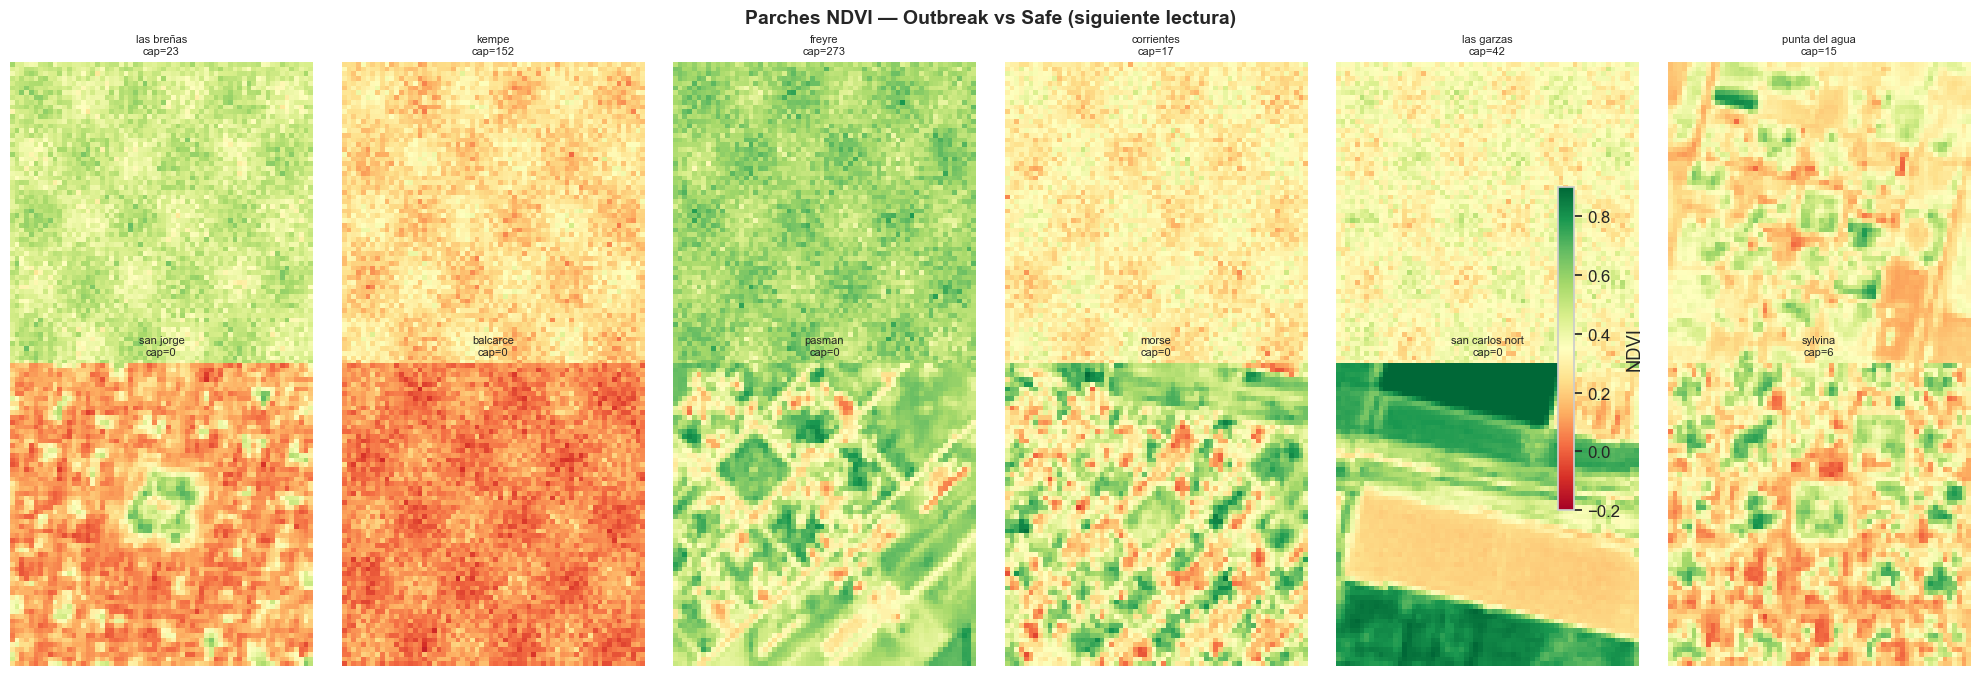

In [9]:
# 3.1 Mosaico de parches NDVI: outbreak vs safe
fig, axes = plt.subplots(2, 6, figsize=(20, 7))

for row_idx, (target_val, label) in enumerate([(1, 'Outbreak next'), (0, 'Safe next')]):
    mask = y == target_val
    indices = df[mask].sample(6, random_state=42).index.tolist()
    for col_idx, idx in enumerate(indices):
        ax = axes[row_idx, col_idx]
        im = ax.imshow(ndvi_patches[idx], cmap='RdYlGn', vmin=-0.2, vmax=0.9)
        loc = df.loc[idx, 'localidad'][:15]
        cap = df.loc[idx, 'capturas_actual']
        ax.set_title(f'{loc}\ncap={cap:.0f}', fontsize=8)
        ax.axis('off')
    axes[row_idx, 0].set_ylabel(label, fontsize=12, fontweight='bold')

fig.colorbar(im, ax=axes, shrink=0.6, label='NDVI')
plt.suptitle('Parches NDVI — Outbreak vs Safe (siguiente lectura)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

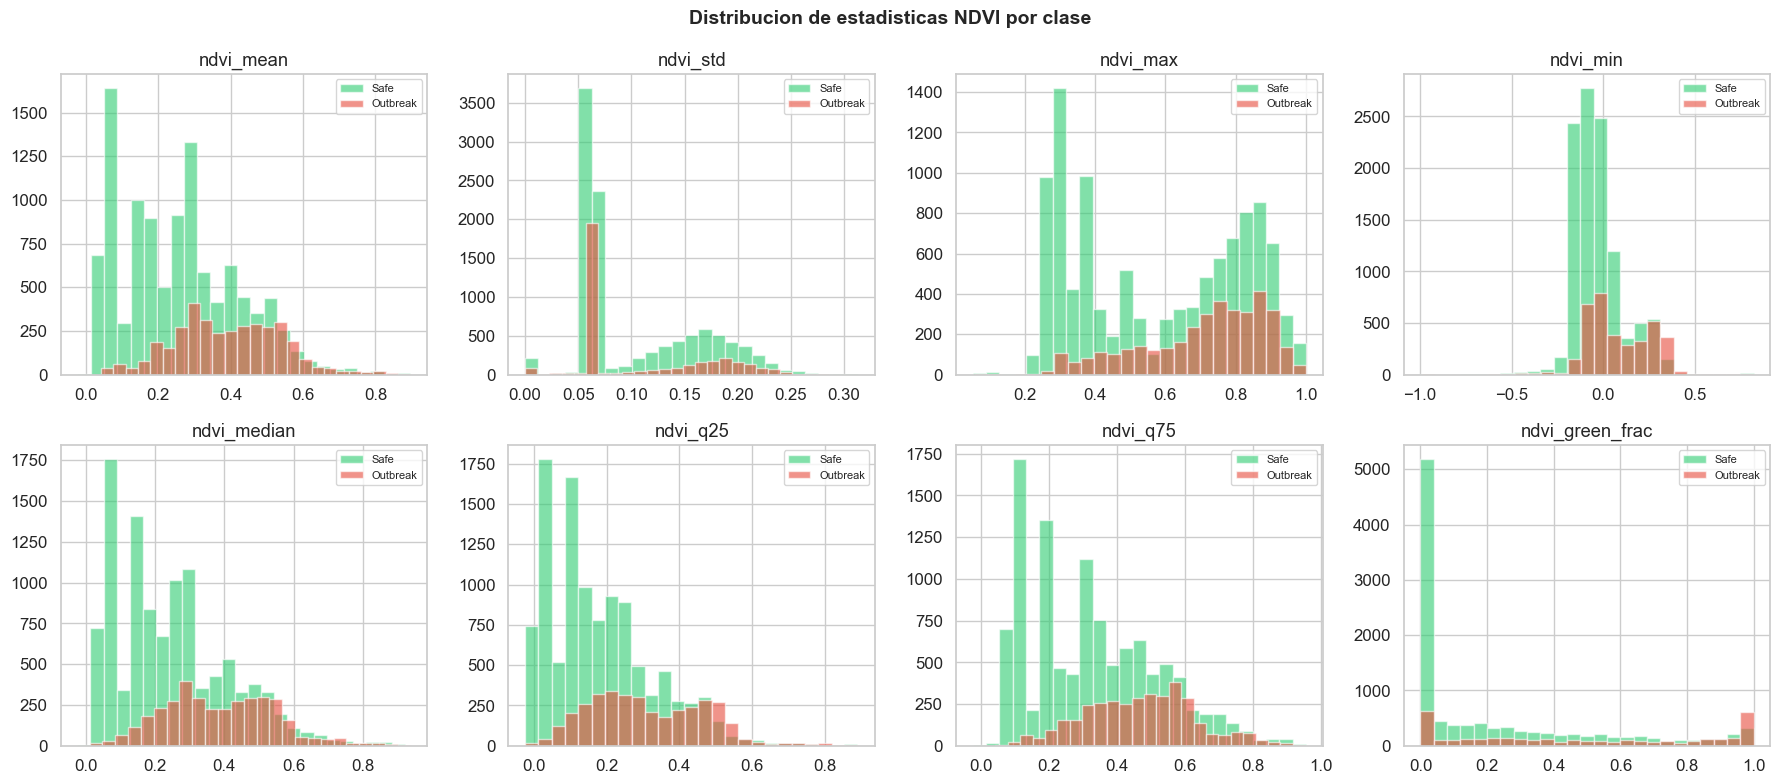

Test Mann-Whitney U (NDVI features por clase):
  ndvi_mean           : p=0.0000 ***
  ndvi_std            : p=0.0008 ***
  ndvi_max            : p=0.0000 ***
  ndvi_min            : p=0.0000 ***
  ndvi_median         : p=0.0000 ***
  ndvi_q25            : p=0.0000 ***
  ndvi_q75            : p=0.0000 ***
  ndvi_green_frac     : p=0.0000 ***


In [10]:
# 3.2 Estadisticas NDVI por clase
ndvi_stats = pd.DataFrame({
    'ndvi_mean': [p.mean() for p in ndvi_patches],
    'ndvi_std': [p.std() for p in ndvi_patches],
    'ndvi_max': [p.max() for p in ndvi_patches],
    'ndvi_min': [p.min() for p in ndvi_patches],
    'ndvi_median': [np.median(p) for p in ndvi_patches],
    'ndvi_q25': [np.percentile(p, 25) for p in ndvi_patches],
    'ndvi_q75': [np.percentile(p, 75) for p in ndvi_patches],
    'ndvi_green_frac': [(p > 0.4).mean() for p in ndvi_patches],
    'target': y.values,
})

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, col in zip(axes.flat, ndvi_stats.columns[:-1]):
    for t, color, label in [(0, TARGET_COLORS[0], 'Safe'), (1, TARGET_COLORS[1], 'Outbreak')]:
        mask_t = ndvi_stats['target'] == t
        ax.hist(ndvi_stats.loc[mask_t, col], bins=25, alpha=0.6,
                color=color, label=label, edgecolor='white')
    ax.set_title(col)
    ax.legend(fontsize=8)

plt.suptitle('Distribucion de estadisticas NDVI por clase',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Test estadistico
from scipy.stats import mannwhitneyu
print('Test Mann-Whitney U (NDVI features por clase):')
for col in ndvi_stats.columns[:-1]:
    safe = ndvi_stats.loc[ndvi_stats['target'] == 0, col]
    outbreak = ndvi_stats.loc[ndvi_stats['target'] == 1, col]
    stat, pval = mannwhitneyu(safe, outbreak, alternative='two-sided')
    sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'
    print(f'  {col:20s}: p={pval:.4f} {sig}')

## 3.5. Features tabulares (`03_modelo_14d.ipynb`)

Las features (espacio, clima, temporada, geografía) están en `output/dataset_14d.csv`. Se hace *merge* interno por **(localidad, provincia, temporada, fecha_inicio)** con los pares de esta notebook y se **reordenan** los parches NDVI para coincidir con las filas resultantes.

**Prerrequisito**: generar `output/dataset_14d.csv` con `03_modelo_14d.ipynb` (o el pipeline equivalente).

In [11]:
if globals().get('HYBRID_FROM_BUNDLE'):
    raise RuntimeError(
        'Ya cargaste el bundle: no ejecutes el merge (§3.5). Seguí desde la §4.'
    )

# --- Cargar dataset tabular pre-computado en notebook 03 ---
df_tabular = pd.read_csv(
    'output/dataset_14d.csv',
    parse_dates=['fecha_inicio', 'fecha_fin', 'fecha_mid',
                 'next_fecha_inicio', 'next_fecha_fin'],
)

# Definir columnas de features vs metadata (mismo criterio que notebook 03)
meta_cols = [
    'localidad', 'provincia', 'region', 'temporada',
    'fecha_inicio', 'fecha_fin', 'fecha_mid',
    'next_fecha_inicio', 'next_fecha_fin',
    'target', 'next_capturas', 'day_of_year',
]
feature_cols = [c for c in df_tabular.columns if c not in meta_cols]

# Verificar alineacion: los pares deben coincidir 1:1 con df cargado en celda 4
# Merge por clave unica de par
merge_key = ['localidad', 'provincia', 'temporada', 'fecha_inicio']
df_merged = df.merge(
    df_tabular[merge_key + feature_cols],
    on=merge_key,
    how='inner',
    suffixes=('', '_tab'),
)

# Eliminar columnas duplicadas del merge (las _tab que ya existian en df)
dup_cols = [c for c in df_merged.columns if c.endswith('_tab')]
df_merged = df_merged.drop(columns=dup_cols)

# Actualizar df, y, masks alineados
df = df_merged.reset_index(drop=True)
y = df['target']
train_mask = df['temporada'] == '2024-2025'
test_mask = df['temporada'] == '2025-2026'

# Extraer matriz tabular
X_tabular = df[feature_cols]

# Re-alinear ndvi_array al nuevo orden (post-merge puede cambiar indices)
# Para esto necesitamos re-indexar ndvi_patches
# Creamos un dict: (localidad, provincia, temporada, fecha_inicio) -> ndvi_patch
print("Re-alineando NDVI con dataset tabular...")
ndvi_key_map = {}
for i, row in enumerate(pairs):
    key = (
        row['localidad'],
        row['provincia'],
        row['temporada'],
        row['fecha_inicio'],
    )
    ndvi_key_map[key] = ndvi_patches[i]

ndvi_aligned = []
dropped = 0
for _, row in df.iterrows():
    key = (row['localidad'], row['provincia'], row['temporada'],
           row['fecha_inicio'])
    patch = ndvi_key_map.get(key)
    if patch is not None:
        ndvi_aligned.append(patch)
    else:
        # Fallback: parche neutro (no deberia pasar si merge es inner)
        ndvi_aligned.append(np.full((NDVI_PATCH_SIZE, NDVI_PATCH_SIZE), 0.3, dtype=np.float32))
        dropped += 1

ndvi_array = np.stack(ndvi_aligned)

print(f"Dataset alineado: {len(df)} pares")
print(f"  Features tabulares: {len(feature_cols)} ({', '.join(feature_cols[:5])}...)")
print(f"  NDVI array: {ndvi_array.shape}")
print(f"  Train: {train_mask.sum()} | Test: {test_mask.sum()}")
print(f"  Target=1: {y.sum()} ({y.mean():.1%})")
if dropped > 0:
    print(f"  WARNING: {dropped} pares sin NDVI match (fallback a 0.3)")
ndvi_patches = list(ndvi_array)
print(f"\nNaN check: {X_tabular.isna().sum().sum()} NaN totales en features")

# Bundle para la celda Atajo (Receta A): por defecto se escribe siempre tras un merge OK.
GUARDAR_BUNDLE_TRAS_MERGE = True
_bundle_root = Path('output/hybrid_14d_ready')
if GUARDAR_BUNDLE_TRAS_MERGE:
    _bundle_root.mkdir(parents=True, exist_ok=True)
    df.to_parquet(_bundle_root / 'df.parquet', index=False)
    np.save(_bundle_root / 'ndvi_array.npy', ndvi_array)
    (_bundle_root / 'feature_cols.json').write_text(
        json.dumps(feature_cols), encoding='utf-8'
    )
    print(
        f"\nBundle guardado en {_bundle_root}/ "
        '(df.parquet, ndvi_array.npy, feature_cols.json). '
        'Próxima corrida: setup + Atajo con USAR_BUNDLE_GUARDADO=True.'
    )

Re-alineando NDVI con dataset tabular...
Dataset alineado: 16370 pares
  Features tabulares: 44 (lat, lon, capturas_actual, capturas_mean_actual, capturas_prev...)
  NDVI array: (16370, 64, 64)
  Train: 10233 | Test: 6137
  Target=1: 3873 (23.7%)

NaN check: 0 NaN totales en features

Bundle guardado en output/hybrid_14d_ready/ (df.parquet, ndvi_array.npy, feature_cols.json). Próxima corrida: setup + Atajo con USAR_BUNDLE_GUARDADO=True.


## 4. Modelo híbrido: CNN (NDVI) + MLP (Tabular)

### Arquitectura detallada (baseline)

```
┌──────────────────────────┐    ┌──────────────────────────┐
│   CNN Branch (NDVI)      │    │   MLP Branch (Tabular)   │
│                          │    │                          │
│   Input: (1, 64, 64)    │    │   Input: (N_feat,)       │
│   Conv2d(1→16, 3)→BN    │    │   Linear→BN→ReLU→Drop   │
│   →ReLU→MaxPool(2)      │    │   Linear→BN→ReLU→Drop   │
│   Conv2d(16→32, 3)→BN   │    │   Linear→32d             │
│   →ReLU→MaxPool(2)      │    │                          │
│   Conv2d(32→64, 3)→BN   │    └───────────┬──────────────┘
│   →ReLU→AdaptAvgPool(4) │                │
│   Flatten→Dense(128)    │                │
│   →Dense(32)            │                │
└───────────┬──────────────┘                │
            │                               │
            └───────────┬───────────────────┘
                        │ Concat (64d)
                        ▼
              ┌──────────────────┐
              │   Fusion Head    │
              │   Dense(64→32)   │
              │   →ReLU→Drop(0.2)│
              │   Dense(32→1)    │
              └──────────────────┘
```

Un experimento alternativo (CNN más grande, pérdida auxiliar, LR desacoplado) está en la **§10** al final del notebook; no modifica este bloque.


In [12]:
class CNNBranch(nn.Module):
    """Red convolucional para procesar parches NDVI."""
    def __init__(self, embedding_dim=32):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(4),
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 4 * 4, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, embedding_dim),
        )

    def forward(self, x):
        x = self.features(x)
        return self.head(x)


class TabularBranch(nn.Module):
    """MLP para features tabulares."""
    def __init__(self, n_features, embedding_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, embedding_dim),
        )

    def forward(self, x):
        return self.net(x)


class HybridModel(nn.Module):
    """Modelo hibrido: CNN(NDVI) + MLP(tabular) -> fusion -> prediccion."""
    def __init__(self, n_tabular_features, cnn_embed=32, tab_embed=32):
        super().__init__()
        self.cnn_branch = CNNBranch(embedding_dim=cnn_embed)
        self.tabular_branch = TabularBranch(n_tabular_features, embedding_dim=tab_embed)

        fusion_dim = cnn_embed + tab_embed
        self.fusion = nn.Sequential(
            nn.Linear(fusion_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1),
        )

    def forward(self, ndvi_patch, tabular_features):
        cnn_emb = self.cnn_branch(ndvi_patch)
        tab_emb = self.tabular_branch(tabular_features)
        combined = torch.cat([cnn_emb, tab_emb], dim=1)
        return self.fusion(combined).squeeze(1)

    def get_embeddings(self, ndvi_patch, tabular_features):
        """Retorna embeddings individuales para analisis."""
        cnn_emb = self.cnn_branch(ndvi_patch)
        tab_emb = self.tabular_branch(tabular_features)
        return cnn_emb, tab_emb


hybrid_model = HybridModel(n_tabular_features=len(feature_cols)).to(DEVICE)
n_params = sum(p.numel() for p in hybrid_model.parameters())
n_cnn = sum(p.numel() for p in hybrid_model.cnn_branch.parameters())
n_tab = sum(p.numel() for p in hybrid_model.tabular_branch.parameters())
n_fus = sum(p.numel() for p in hybrid_model.fusion.parameters())

print(f'Modelo hibrido creado en {DEVICE}:')
print(f'  CNN branch:     {n_cnn:>8,} params')
print(f'  Tabular branch: {n_tab:>8,} params')
print(f'  Fusion head:    {n_fus:>8,} params')
print(f'  TOTAL:          {n_params:>8,} params')
print(f'\n{hybrid_model}')


Modelo hibrido creado en mps:
  CNN branch:      158,848 params
  Tabular branch:   16,480 params
  Fusion head:       2,113 params
  TOTAL:           177,441 params

HybridModel(
  (cnn_branch): CNNBranch(
    (features): Sequential(
      (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (5): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU()
      (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (8): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (9): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (10): ReLU()
      (11): AdaptiveAvgPool2d(outpu

In [13]:
class ChicharritaDataset(Dataset):
    """Dataset que combina parches NDVI + features tabulares."""

    def __init__(self, ndvi_patches, tabular_features, targets, scaler=None):
        self.ndvi = torch.FloatTensor(ndvi_patches).unsqueeze(1)  # (N, 1, H, W)
        if scaler is not None:
            tabular_features = scaler.transform(tabular_features)
        self.tabular = torch.FloatTensor(tabular_features)
        self.targets = torch.FloatTensor(targets)

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        return self.ndvi[idx], self.tabular[idx], self.targets[idx]


scaler = StandardScaler()
X_tab_train = scaler.fit_transform(X_tabular[train_mask].values)
X_tab_test = scaler.transform(X_tabular[test_mask].values)

ndvi_train = ndvi_array[train_mask.values]
ndvi_test = ndvi_array[test_mask.values]
y_train = y[train_mask].values.astype(np.float32)
y_test = y[test_mask].values.astype(np.float32)

train_dataset = ChicharritaDataset(ndvi_train, X_tab_train, y_train)
test_dataset = ChicharritaDataset(ndvi_test, X_tab_test, y_test)

BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f'Train: {len(train_dataset)} samples, {len(train_loader)} batches')
print(f'Test:  {len(test_dataset)} samples, {len(test_loader)} batches')
print(f'NDVI shape per sample:    {train_dataset[0][0].shape}')
print(f'Tabular shape per sample: {train_dataset[0][1].shape}')


Train: 10233 samples, 160 batches
Test:  6137 samples, 96 batches
NDVI shape per sample:    torch.Size([1, 64, 64])
Tabular shape per sample: torch.Size([44])


## 5. Entrenamiento

- **Focal Loss** para manejar desbalance de clases (α=0.6, γ=2.0)
- **AdamW** con weight decay + cosine annealing LR
- **Early stopping** sobre AUC del test set (patience=15)

In [14]:
class FocalLoss(nn.Module):
    """Focal Loss para clasificacion desbalanceada."""
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        bce = nn.functional.binary_cross_entropy_with_logits(
            inputs, targets, reduction='none'
        )
        probs = torch.sigmoid(inputs)
        pt = torch.where(targets == 1, probs, 1 - probs)
        alpha_t = torch.where(targets == 1, self.alpha, 1 - self.alpha)
        focal_weight = alpha_t * (1 - pt) ** self.gamma
        return (focal_weight * bce).mean()


def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    for ndvi, tabular, targets in loader:
        ndvi = ndvi.to(DEVICE)
        tabular = tabular.to(DEVICE)
        targets = targets.to(DEVICE)
        optimizer.zero_grad()
        logits = model(ndvi, tabular)
        loss = criterion(logits, targets)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(targets)
    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_probs, all_targets = [], []
    total_loss = 0
    criterion = FocalLoss(alpha=0.6, gamma=2.0)
    for ndvi, tabular, targets in loader:
        ndvi = ndvi.to(DEVICE)
        tabular = tabular.to(DEVICE)
        targets = targets.to(DEVICE)
        logits = model(ndvi, tabular)
        loss = criterion(logits, targets)
        total_loss += loss.item() * len(targets)
        probs = torch.sigmoid(logits).cpu().numpy()
        all_probs.extend(probs)
        all_targets.extend(targets.cpu().numpy())

    all_probs = np.array(all_probs)
    all_targets = np.array(all_targets)
    n_unique = len(np.unique(all_targets))
    auc = roc_auc_score(all_targets, all_probs) if n_unique > 1 else 0.5
    ap = average_precision_score(all_targets, all_probs) if n_unique > 1 else 0.0
    return total_loss / len(loader.dataset), auc, ap, all_probs, all_targets


hybrid_model = HybridModel(n_tabular_features=len(feature_cols)).to(DEVICE)
criterion = FocalLoss(alpha=0.6, gamma=2.0)
optimizer = optim.AdamW(hybrid_model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-5)

N_EPOCHS = 80
PATIENCE = 15
best_auc = 0
patience_counter = 0
history = {'train_loss': [], 'test_loss': [], 'test_auc': [], 'test_ap': []}

print(f'Entrenando modelo hibrido ({N_EPOCHS} epochs max, patience={PATIENCE})...\n')

for epoch in range(N_EPOCHS):
    train_loss = train_epoch(hybrid_model, train_loader, criterion, optimizer)
    test_loss, test_auc, test_ap, _, _ = evaluate(hybrid_model, test_loader)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['test_loss'].append(test_loss)
    history['test_auc'].append(test_auc)
    history['test_ap'].append(test_ap)

    improved = test_auc > best_auc
    if improved:
        best_auc = test_auc
        patience_counter = 0
        torch.save(hybrid_model.state_dict(), 'output/hybrid_model_best.pt')
    else:
        patience_counter += 1

    if (epoch + 1) % 10 == 0 or improved:
        lr = optimizer.param_groups[0]['lr']
        marker = ' <- best' if improved else ''
        print(
            f'  Epoch {epoch+1:3d} | Train: {train_loss:.4f} | '
            f'Test: {test_loss:.4f} | AUC: {test_auc:.3f} | '
            f'AP: {test_ap:.3f} | LR: {lr:.1e}{marker}'
        )

    if patience_counter >= PATIENCE:
        print(f'\n  Early stopping at epoch {epoch+1} (best AUC: {best_auc:.3f})')
        break

hybrid_model.load_state_dict(
    torch.load('output/hybrid_model_best.pt', map_location=DEVICE, weights_only=True)
)
print(f'\nMejor modelo cargado (AUC = {best_auc:.3f})')


Entrenando modelo hibrido (80 epochs max, patience=15)...

  Epoch   1 | Train: 0.0338 | Test: 0.0357 | AUC: 0.945 | AP: 0.860 | LR: 1.0e-03 <- best
  Epoch   2 | Train: 0.0273 | Test: 0.0347 | AUC: 0.945 | AP: 0.862 | LR: 1.0e-03 <- best
  Epoch   3 | Train: 0.0263 | Test: 0.0339 | AUC: 0.948 | AP: 0.870 | LR: 9.9e-04 <- best
  Epoch   5 | Train: 0.0255 | Test: 0.0349 | AUC: 0.949 | AP: 0.871 | LR: 9.8e-04 <- best
  Epoch  10 | Train: 0.0243 | Test: 0.0345 | AUC: 0.945 | AP: 0.869 | LR: 9.1e-04
  Epoch  18 | Train: 0.0232 | Test: 0.0348 | AUC: 0.949 | AP: 0.870 | LR: 7.2e-04 <- best
  Epoch  20 | Train: 0.0225 | Test: 0.0364 | AUC: 0.944 | AP: 0.866 | LR: 6.6e-04
  Epoch  30 | Train: 0.0217 | Test: 0.0431 | AUC: 0.931 | AP: 0.858 | LR: 3.5e-04

  Early stopping at epoch 33 (best AUC: 0.949)

Mejor modelo cargado (AUC = 0.949)


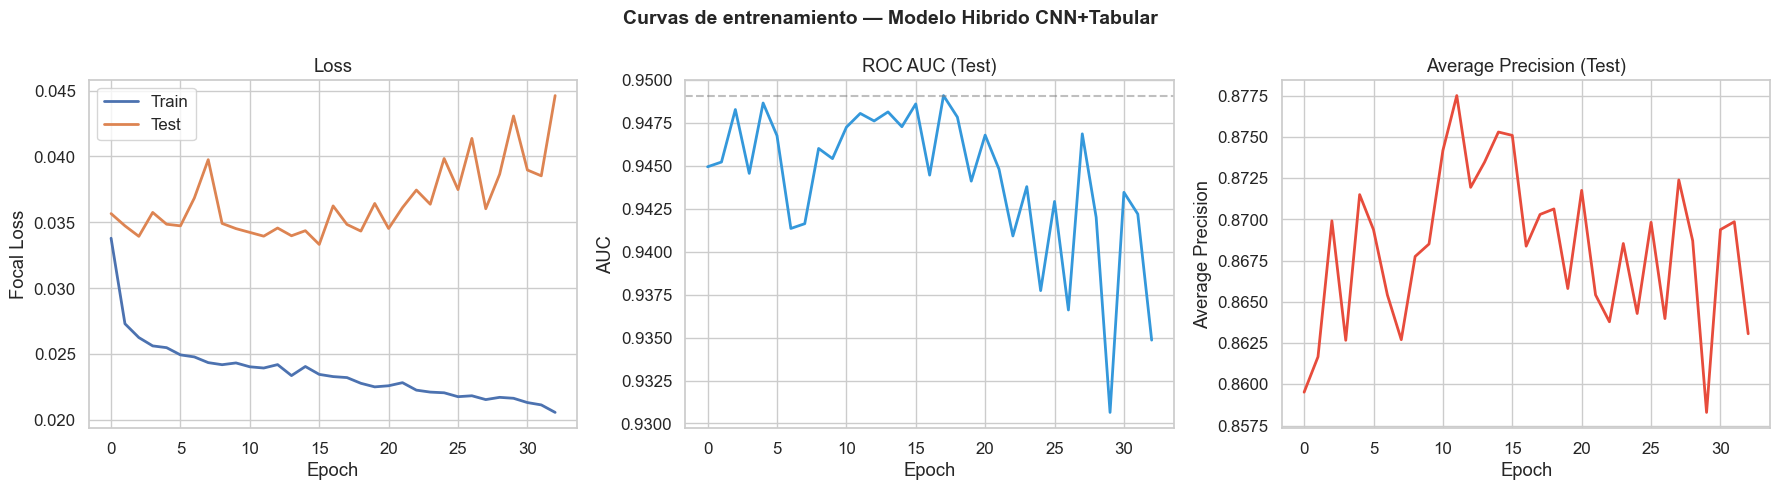

In [15]:
# Curvas de entrenamiento
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history['train_loss'], label='Train', linewidth=2)
axes[0].plot(history['test_loss'], label='Test', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Focal Loss')
axes[0].set_title('Loss')
axes[0].legend()

axes[1].plot(history['test_auc'], label='AUC', linewidth=2, color='#3498db')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC')
axes[1].set_title('ROC AUC (Test)')
axes[1].axhline(best_auc, linestyle='--', color='gray', alpha=0.5)

axes[2].plot(history['test_ap'], label='AP', linewidth=2, color='#e74c3c')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Average Precision')
axes[2].set_title('Average Precision (Test)')

plt.suptitle('Curvas de entrenamiento — Modelo Hibrido CNN+Tabular',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Evaluación del modelo híbrido

In [16]:
# Evaluar modelo final
_, final_auc, final_ap, y_pred_proba_hybrid, y_test_arr = evaluate(
    hybrid_model, test_loader
)

# Buscar mejor threshold por F1
thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = [
    f1_score(y_test_arr, (y_pred_proba_hybrid >= t).astype(int), zero_division=0)
    for t in thresholds
]
best_threshold = thresholds[np.argmax(f1_scores)]
y_pred_hybrid = (y_pred_proba_hybrid >= best_threshold).astype(int)

print(f"{'='*55}")
print(f'RESULTADOS — Modelo Hibrido CNN(NDVI) + Tabular')
print(f"{'='*55}")
print(f'ROC AUC:           {final_auc:.3f}')
print(f'Average Precision: {final_ap:.3f}')
print(f'Best F1:           {max(f1_scores):.3f} (threshold={best_threshold:.2f})')
print(f'\n{classification_report(y_test_arr, y_pred_hybrid, target_names=["Safe", "Outbreak"], zero_division=0)}')

RESULTADOS — Modelo Hibrido CNN(NDVI) + Tabular
ROC AUC:           0.949
Average Precision: 0.870
Best F1:           0.804 (threshold=0.52)

              precision    recall  f1-score   support

        Safe       0.94      0.91      0.93      4502
    Outbreak       0.78      0.83      0.80      1635

    accuracy                           0.89      6137
   macro avg       0.86      0.87      0.86      6137
weighted avg       0.89      0.89      0.89      6137



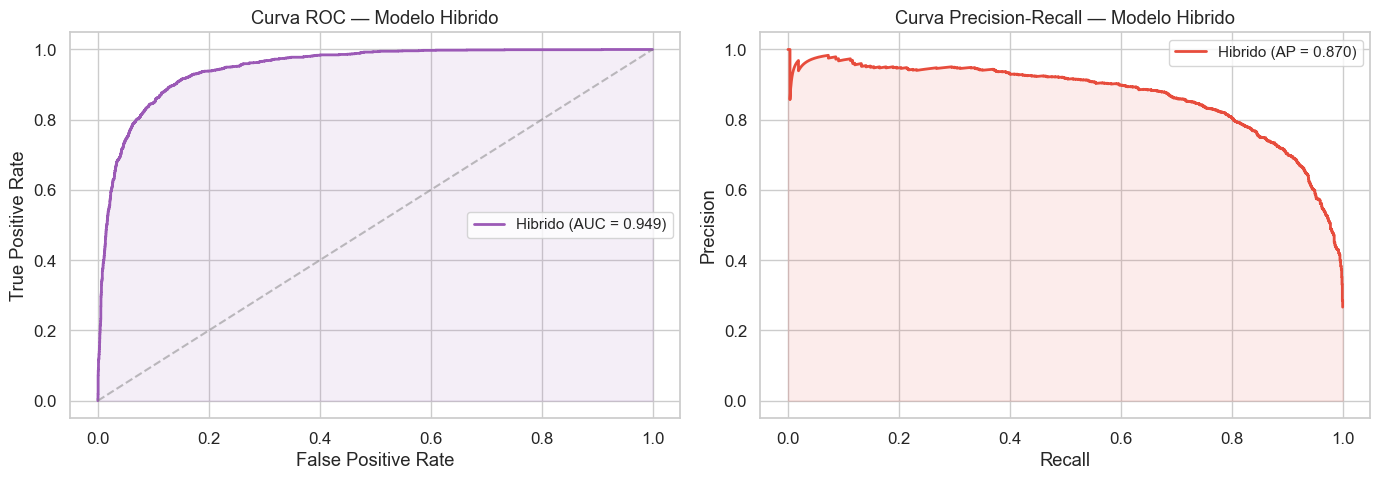

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC
fpr, tpr, _ = roc_curve(y_test_arr, y_pred_proba_hybrid)
axes[0].plot(fpr, tpr, linewidth=2, color='#9b59b6',
             label=f'Hibrido (AUC = {final_auc:.3f})')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', alpha=0.5)
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#9b59b6')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Curva ROC — Modelo Hibrido')
axes[0].legend(fontsize=11)

# Precision-Recall
prec, rec, _ = precision_recall_curve(y_test_arr, y_pred_proba_hybrid)
axes[1].plot(rec, prec, linewidth=2, color='#e74c3c',
             label=f'Hibrido (AP = {final_ap:.3f})')
axes[1].fill_between(rec, prec, alpha=0.1, color='#e74c3c')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Curva Precision-Recall — Modelo Hibrido')
axes[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

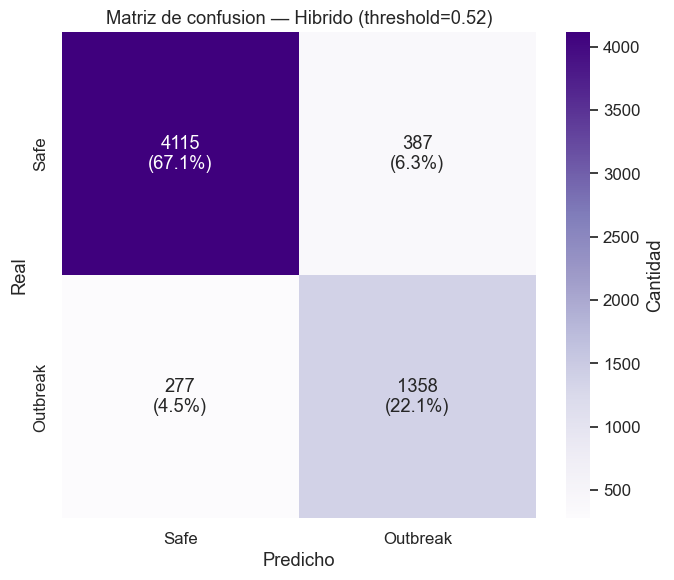

In [18]:
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_test_arr, y_pred_hybrid)
labels = np.array([[f'{v}\n({v/cm.sum()*100:.1f}%)' for v in row] for row in cm])
sns.heatmap(
    cm, annot=labels, fmt='', cmap='Purples', ax=ax,
    xticklabels=['Safe', 'Outbreak'], yticklabels=['Safe', 'Outbreak'],
    cbar_kws={'label': 'Cantidad'},
)
ax.set_xlabel('Predicho')
ax.set_ylabel('Real')
ax.set_title(f'Matriz de confusion — Hibrido (threshold={best_threshold:.2f})')
plt.tight_layout()
plt.show()

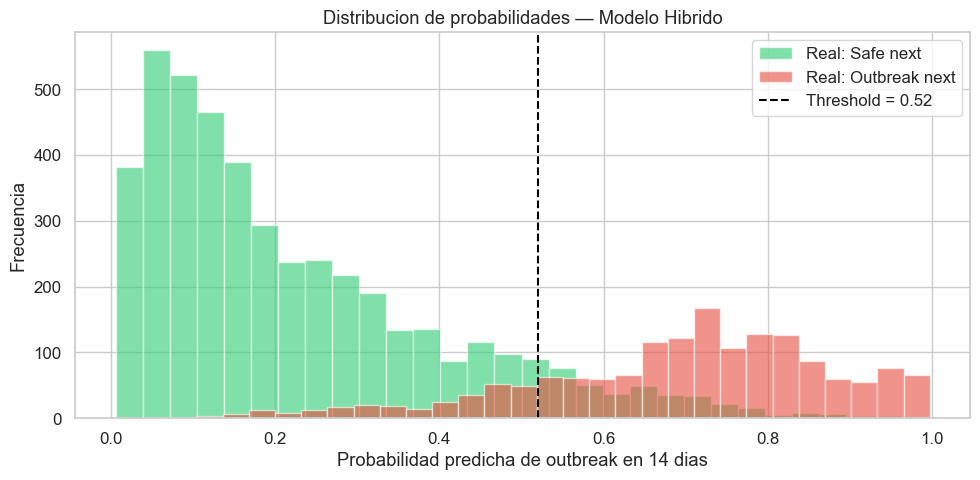

In [19]:
fig, ax = plt.subplots(figsize=(10, 5))
for t, color, label in [
    (0, TARGET_COLORS[0], 'Safe next'),
    (1, TARGET_COLORS[1], 'Outbreak next'),
]:
    mask = y_test_arr == t
    ax.hist(y_pred_proba_hybrid[mask], bins=30, alpha=0.6,
            color=color, label=f'Real: {label}', edgecolor='white')
ax.axvline(
    x=best_threshold, color='black', linestyle='--', linewidth=1.5,
    label=f'Threshold = {best_threshold:.2f}',
)
ax.set_xlabel('Probabilidad predicha de outbreak en 14 dias')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribucion de probabilidades — Modelo Hibrido')
ax.legend()
plt.tight_layout()
plt.show()

## 7. Comparación con baselines (MLP sin satélite, XGBoost, híbrido)

En el **mismo conjunto de test** (temporada 2025-2026) comparamos:

1. **MLP tabular (sin NDVI)** — Pesos `output/mlp_baseline_best.pt` del notebook `03_modelo_14d.ipynb` (sección 12). Misma arquitectura que la rama tabular + cabeza de fusión del híbrido, entrenada solo con features tabulares. Las probabilidades se calculan con el `StandardScaler` ajustado **en este cuaderno** sobre el train mergeado (mismas filas y columnas que el híbrido si `dataset_14d` coincide con los pares).
2. **XGBoost tabular** — Solo features tabulares.
3. **XGBoost + estadísticas NDVI** — Tabulares más resúmenes escalar del parche (media, std, fracción verde, etc.).
4. **Híbrido CNN + tabular** — Resultados de la sección 6.

Si falta el checkpoint del MLP, la fila correspondiente se omite en la tabla y en las leyendas.

In [20]:
# --- 0) MLP tabular sin satélite (checkpoint desde 03_modelo_14d.ipynb) ---
class TabularMLPModel(nn.Module):
    """Igual que sección 12 de 03_modelo_14d: rama tabular + cabeza de fusión, sin CNN."""

    def __init__(self, n_features, embedding_dim=32):
        super().__init__()
        self.tabular_branch = nn.Sequential(
            nn.Linear(n_features, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, embedding_dim),
        )
        self.fusion = nn.Sequential(
            nn.Linear(embedding_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        emb = self.tabular_branch(x)
        return self.fusion(emb).squeeze(1)


mlp_ckpt = Path('output/mlp_baseline_best.pt')
y_pred_mlp_tab = None
auc_mlp_tab = ap_mlp_tab = None

if mlp_ckpt.is_file():
    mlp_tab = TabularMLPModel(n_features=len(feature_cols)).to(DEVICE)
    mlp_tab.load_state_dict(
        torch.load(mlp_ckpt, map_location=DEVICE, weights_only=True)
    )
    mlp_tab.eval()
    probs_list = []
    with torch.no_grad():
        for i in range(0, len(X_tab_test), 512):
            batch = torch.FloatTensor(X_tab_test[i : i + 512]).to(DEVICE)
            probs_list.append(torch.sigmoid(mlp_tab(batch)).cpu().numpy())
    y_pred_mlp_tab = np.concatenate(probs_list)
    auc_mlp_tab = roc_auc_score(y_test_arr, y_pred_mlp_tab)
    ap_mlp_tab = average_precision_score(y_test_arr, y_pred_mlp_tab)
    print(f'MLP tabular (sin NDVI): AUC={auc_mlp_tab:.4f} | AP={ap_mlp_tab:.4f} [{mlp_ckpt}]')
else:
    print(f'No hay {mlp_ckpt}: ejecutar sección 12 de 03_modelo_14d.ipynb para comparar MLP.')

# --- A) XGBoost base (solo tabular) ---
n_pos = y_train.sum()
n_neg = len(y_train) - n_pos
scale = n_neg / n_pos if n_pos > 0 else 1.0

xgb_base = XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.7,
    reg_alpha=1.0, reg_lambda=1.0, min_child_weight=5,
    scale_pos_weight=scale, eval_metric='logloss', random_state=42,
)
xgb_base.fit(X_tabular[train_mask], y[train_mask], verbose=False)
y_pred_xgb_base = xgb_base.predict_proba(X_tabular[test_mask])[:, 1]
auc_xgb_base = roc_auc_score(y_test_arr, y_pred_xgb_base)
ap_xgb_base = average_precision_score(y_test_arr, y_pred_xgb_base)

# --- B) XGBoost + NDVI stats ---
ndvi_stat_df = pd.DataFrame(
    {
        'ndvi_mean': ndvi_array.mean(axis=(1, 2)),
        'ndvi_std': ndvi_array.std(axis=(1, 2)),
        'ndvi_max': ndvi_array.max(axis=(1, 2)),
        'ndvi_min': ndvi_array.min(axis=(1, 2)),
        'ndvi_median': np.median(ndvi_array, axis=(1, 2)),
        'ndvi_q25': np.percentile(ndvi_array, 25, axis=(1, 2)),
        'ndvi_q75': np.percentile(ndvi_array, 75, axis=(1, 2)),
        'ndvi_green_frac': (ndvi_array > 0.4).mean(axis=(1, 2)),
    },
    index=df.index,
)
X_with_ndvi = pd.concat([X_tabular, ndvi_stat_df], axis=1)

xgb_ndvi = XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.7,
    reg_alpha=1.0, reg_lambda=1.0, min_child_weight=5,
    scale_pos_weight=scale, eval_metric='logloss', random_state=42,
)
xgb_ndvi.fit(X_with_ndvi[train_mask], y[train_mask], verbose=False)
y_pred_xgb_ndvi = xgb_ndvi.predict_proba(X_with_ndvi[test_mask])[:, 1]
auc_xgb_ndvi = roc_auc_score(y_test_arr, y_pred_xgb_ndvi)
ap_xgb_ndvi = average_precision_score(y_test_arr, y_pred_xgb_ndvi)

# --- Tabla comparativa ---
comp_thresholds = np.arange(0.1, 0.9, 0.01)


def _best_f1(y_true, y_score):
    return max(
        f1_score(y_true, (y_score >= t).astype(int), zero_division=0)
        for t in comp_thresholds
    )


comp_rows = []
if y_pred_mlp_tab is not None:
    comp_rows.append({
        'Modelo': 'MLP tabular (sin NDVI, notebook 03)',
        'ROC AUC': auc_mlp_tab,
        'Avg Precision': ap_mlp_tab,
        'Best F1': _best_f1(y_test_arr, y_pred_mlp_tab),
    })
comp_rows.extend([
    {
        'Modelo': 'XGBoost (solo tabular)',
        'ROC AUC': auc_xgb_base,
        'Avg Precision': ap_xgb_base,
        'Best F1': _best_f1(y_test_arr, y_pred_xgb_base),
    },
    {
        'Modelo': 'XGBoost + estadísticas NDVI',
        'ROC AUC': auc_xgb_ndvi,
        'Avg Precision': ap_xgb_ndvi,
        'Best F1': _best_f1(y_test_arr, y_pred_xgb_ndvi),
    },
    {
        'Modelo': 'Híbrido CNN (NDVI) + tabular',
        'ROC AUC': final_auc,
        'Avg Precision': final_ap,
        'Best F1': float(max(f1_scores)),
    },
])
comparison = pd.DataFrame(comp_rows)

print('=' * 72)
print('COMPARACIÓN EN TEST 2025-2026 (mismas filas que el híbrido)')
print('=' * 72)
display(comparison.round(4))

MLP tabular (sin NDVI): AUC=0.9497 | AP=0.8734 [output/mlp_baseline_best.pt]
COMPARACIÓN EN TEST 2025-2026 (mismas filas que el híbrido)


,Modelo,ROC AUC,Avg Precision,Best F1
0,"MLP tabular (sin NDVI, notebook 03)",0.9497,0.8734,0.8017
1,XGBoost (solo tabular),0.9465,0.8694,0.8007
2,XGBoost + estadísticas NDVI,0.9459,0.8699,0.8017
3,Híbrido CNN (NDVI) + tabular,0.9491,0.8703,0.8036


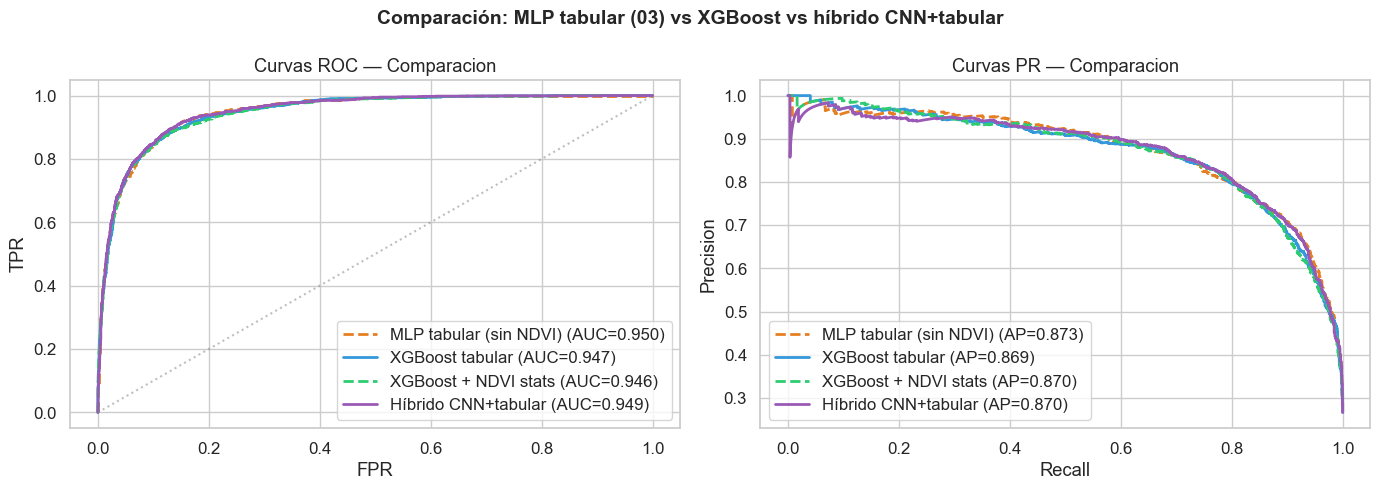

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

models_info = []
if y_pred_mlp_tab is not None:
    models_info.append(
        ('MLP tabular (sin NDVI)', y_pred_mlp_tab, '#e67e22', '--')
    )
models_info.extend([
    ('XGBoost tabular', y_pred_xgb_base, '#3498db', '-'),
    ('XGBoost + NDVI stats', y_pred_xgb_ndvi, '#2ecc71', '--'),
    ('Híbrido CNN+tabular', y_pred_proba_hybrid, '#9b59b6', '-'),
])

# ROC comparison
for name, probs, color, ls in models_info:
    fpr_c, tpr_c, _ = roc_curve(y_test_arr, probs)
    auc_val = roc_auc_score(y_test_arr, probs)
    axes[0].plot(fpr_c, tpr_c, linewidth=2, color=color, linestyle=ls,
                 label=f'{name} (AUC={auc_val:.3f})')

axes[0].plot([0, 1], [0, 1], linestyle=':', color='gray', alpha=0.5)
axes[0].set_xlabel('FPR')
axes[0].set_ylabel('TPR')
axes[0].set_title('Curvas ROC — Comparacion')
axes[0].legend()

# PR comparison
for name, probs, color, ls in models_info:
    prec_c, rec_c, _ = precision_recall_curve(y_test_arr, probs)
    ap_val = average_precision_score(y_test_arr, probs)
    axes[1].plot(rec_c, prec_c, linewidth=2, color=color, linestyle=ls,
                 label=f'{name} (AP={ap_val:.3f})')

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Curvas PR — Comparacion')
axes[1].legend()

plt.suptitle(
    'Comparación: MLP tabular (03) vs XGBoost vs híbrido CNN+tabular',
    fontsize=14,
    fontweight='bold',
)
plt.tight_layout()
plt.show()

## 8. Análisis de la contribución del CNN (NDVI)

Visualizamos qué aprende la rama CNN a través de:
1. **Grad-CAM** — Mapas de activación que muestran qué regiones del NDVI son más relevantes
2. **t-SNE de embeddings** — Separación de clases en el espacio de representación de cada rama

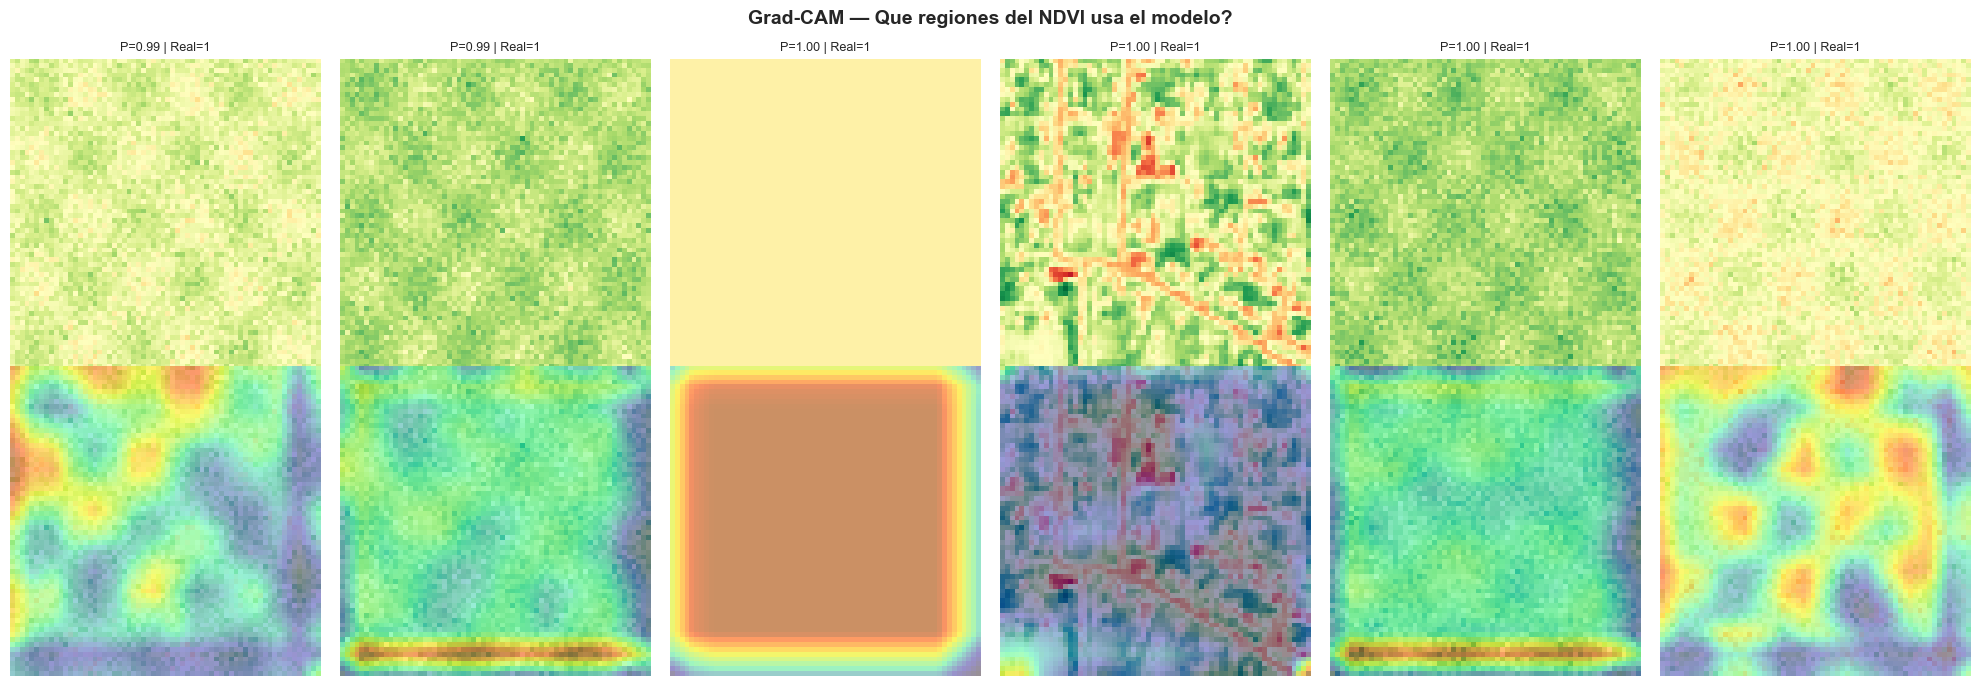

In [24]:
# --- Grad-CAM para la rama CNN ---
def compute_gradcam(model, ndvi_tensor, tabular_tensor):
    """Calcula Grad-CAM sobre la ultima capa convolucional."""
    model.eval()
    activations, gradients = {}, {}

    def fwd_hook(module, inp, out):
        activations['val'] = out

    def bwd_hook(module, grad_in, grad_out):
        gradients['val'] = grad_out[0]

    # Hook en la ultima capa conv (BatchNorm2d antes de AdaptiveAvgPool)
    target_layer = model.cnn_branch.features[-2]
    fh = target_layer.register_forward_hook(fwd_hook)
    bh = target_layer.register_full_backward_hook(bwd_hook)

    ndvi_in = ndvi_tensor.unsqueeze(0).to(DEVICE).requires_grad_(True)
    tab_in = tabular_tensor.unsqueeze(0).to(DEVICE)

    output = model(ndvi_in, tab_in)
    output.backward()

    grads = gradients['val'].squeeze()   # (C, H, W)
    acts = activations['val'].squeeze()  # (C, H, W)
    weights = grads.mean(dim=(1, 2))     # (C,)

    cam = torch.zeros(acts.shape[1:], device=DEVICE)
    for i, w in enumerate(weights):
        cam += w * acts[i]

    cam = torch.relu(cam)
    cam = cam - cam.min()
    if cam.max() > 0:
        cam = cam / cam.max()

    fh.remove()
    bh.remove()
    return cam.detach().cpu().numpy()


# Visualizar Grad-CAM para los 6 casos de mayor riesgo predicho
from scipy.ndimage import zoom as scipy_zoom

high_risk_indices = np.argsort(y_pred_proba_hybrid)[-6:]
fig, axes = plt.subplots(2, 6, figsize=(20, 7))

for col, idx in enumerate(high_risk_indices):
    ndvi_t, tab_t, _ = test_dataset[idx]
    cam = compute_gradcam(hybrid_model, ndvi_t, tab_t)

    # Resize CAM al tamano del patch
    scale_h = NDVI_PATCH_SIZE / cam.shape[0]
    scale_w = NDVI_PATCH_SIZE / cam.shape[1]
    cam_resized = scipy_zoom(cam, (scale_h, scale_w), order=1)

    # NDVI original
    axes[0, col].imshow(ndvi_t.squeeze().numpy(), cmap='RdYlGn', vmin=-0.2, vmax=0.9)
    axes[0, col].set_title(
        f'P={y_pred_proba_hybrid[idx]:.2f} | Real={int(y_test_arr[idx])}', fontsize=9
    )
    axes[0, col].axis('off')

    # Grad-CAM overlay
    axes[1, col].imshow(ndvi_t.squeeze().numpy(), cmap='RdYlGn', vmin=-0.2, vmax=0.9)
    axes[1, col].imshow(cam_resized, cmap='jet', alpha=0.4)
    axes[1, col].axis('off')

axes[0, 0].set_ylabel('NDVI', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Grad-CAM', fontsize=12, fontweight='bold')
plt.suptitle('Grad-CAM — Que regiones del NDVI usa el modelo?',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

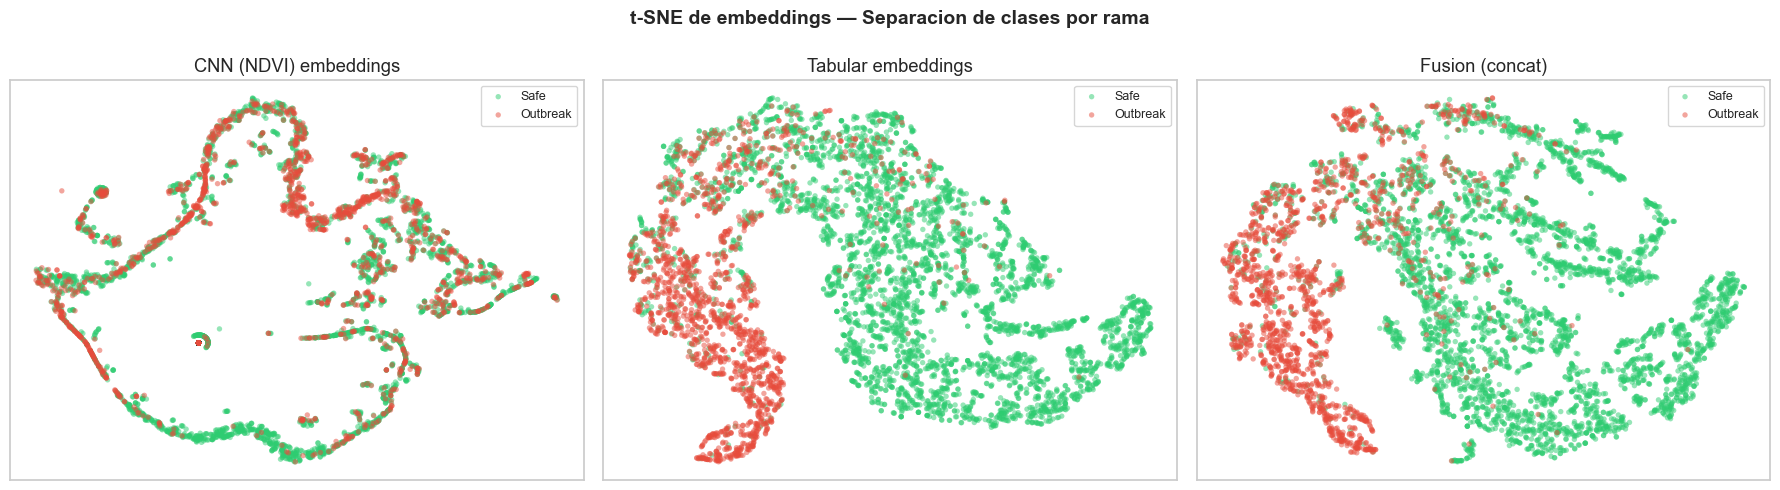

In [25]:
# --- t-SNE de embeddings por rama ---
hybrid_model.eval()
cnn_embeddings, tab_embeddings = [], []

with torch.no_grad():
    for ndvi_b, tab_b, _ in test_loader:
        ndvi_b, tab_b = ndvi_b.to(DEVICE), tab_b.to(DEVICE)
        cnn_emb, tab_emb = hybrid_model.get_embeddings(ndvi_b, tab_b)
        cnn_embeddings.append(cnn_emb.cpu().numpy())
        tab_embeddings.append(tab_emb.cpu().numpy())

cnn_embeddings = np.concatenate(cnn_embeddings)
tab_embeddings = np.concatenate(tab_embeddings)

from sklearn.manifold import TSNE

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, emb, title in [
    (axes[0], cnn_embeddings, 'CNN (NDVI) embeddings'),
    (axes[1], tab_embeddings, 'Tabular embeddings'),
    (axes[2], np.concatenate([cnn_embeddings, tab_embeddings], axis=1), 'Fusion (concat)'),
]:
    perp = min(30, len(emb) - 1)
    tsne = TSNE(n_components=2, random_state=42, perplexity=perp)
    coords = tsne.fit_transform(emb)
    for t, color, label in [
        (0, TARGET_COLORS[0], 'Safe'),
        (1, TARGET_COLORS[1], 'Outbreak'),
    ]:
        mask_t = y_test_arr == t
        ax.scatter(coords[mask_t, 0], coords[mask_t, 1], c=color, label=label,
                   alpha=0.5, s=15, edgecolors='none')
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle('t-SNE de embeddings — Separacion de clases por rama',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 9. Exportar modelo y metadata

Guardamos el modelo híbrido completo (pesos + scaler + config) y la metadata para producción.

In [ ]:
# Guardar modelo completo
torch.save(
    {
        'model_state_dict': hybrid_model.state_dict(),
        'feature_cols': feature_cols,
        'scaler_mean': scaler.mean_.tolist(),
        'scaler_scale': scaler.scale_.tolist(),
        'ndvi_patch_size': NDVI_PATCH_SIZE,
        'ndvi_resolution': NDVI_RESOLUTION,
        'decision_threshold': float(best_threshold),
        'architecture': {
            'cnn_embed': 32,
            'tab_embed': 32,
            'n_tabular_features': len(feature_cols),
        },
    },
    'output/hybrid_model_full.pt',
)

# Metadata
hybrid_meta = {
    'model_type': 'hybrid_cnn_tabular_14d',
    'description': (
        'Modelo hibrido CNN(NDVI) + MLP(tabular) para riesgo '
        'de outbreak de Dalbulus maidis a 14 dias'
    ),
    'ndvi_source': 'Sentinel-2 L2A via CDSE' if USE_REAL_NDVI else 'Sintetico (demo)',
    'ndvi_patch_size': NDVI_PATCH_SIZE,
    'ndvi_resolution_m': NDVI_RESOLUTION,
    'n_tabular_features': len(feature_cols),
    'n_parameters': sum(p.numel() for p in hybrid_model.parameters()),
    'decision_threshold': float(best_threshold),
    'metrics': {
        'roc_auc': float(final_auc),
        'avg_precision': float(final_ap),
        'best_f1': float(max(f1_scores)),
    },
    'comparison': {
        **(
            {'mlp_tabular_no_ndvi_auc': float(auc_mlp_tab)}
            if y_pred_mlp_tab is not None
            else {}
        ),
        'xgb_base_auc': float(auc_xgb_base),
        'xgb_ndvi_stats_auc': float(auc_xgb_ndvi),
        'hybrid_cnn_tabular_auc': float(final_auc),
    },
    'generated_at': datetime.now().isoformat(),
}

with open('output/hybrid_model_metadata.json', 'w') as f:
    json.dump(hybrid_meta, f, indent=2, ensure_ascii=False)

print('Archivos guardados:')
print('  output/hybrid_model_best.pt          — Pesos del mejor modelo (checkpoint)')
print('  output/hybrid_model_full.pt          — Modelo + scaler + config completo')
print('  output/hybrid_model_metadata.json    — Metadata y metricas')
print(f'\nMetricas finales del modelo hibrido:')
print(f'  ROC AUC:    {final_auc:.3f}')
print(f'  Avg Prec:   {final_ap:.3f}')
print(f'  Best F1:    {max(f1_scores):.3f} (threshold={best_threshold:.2f})')
print(f'\nComparación (test):')
if y_pred_mlp_tab is not None:
    print(f'  MLP tabular (sin NDVI): AUC={auc_mlp_tab:.3f}')
print(f'  XGBoost tabular:        AUC={auc_xgb_base:.3f}')
print(f'  XGBoost + NDVI stats:   AUC={auc_xgb_ndvi:.3f}')
print(f'  Híbrido CNN+tabular:    AUC={final_auc:.3f}')


---

## 10. Experimento B — rama NDVI reforzada (no pisa el baseline)

Todo lo de arriba (§4–§9) usa **`hybrid_model`** y guarda en `output/hybrid_model_best.pt`.

Esta sección define **otros módulos** (`CNNBranchExpB`, `HybridModelExpB`, dataset con normalización NDVI + flips) y entrena **`hybrid_model_expb`** → checkpoint **`output/hybrid_expB_best.pt`**.

- **Grad-CAM / t-SNE (§8)** siguen usando el `hybrid_model` baseline salvo que asignes manualmente `hybrid_model = hybrid_model_expb` y vuelvas a ejecutar esas celdas.
- Tras entrenar ExpB, ejecutá **§10.1** para tabla y curvas ROC/PR del ExpB vs MLP, XGBoost y híbrido baseline (idealmente con **§6** y **§7** ya ejecutadas).


In [26]:
# --- Experimento B: arquitectura + datos ---
CNN_EMBED_EXPB = 64
TAB_EMBED_EXPB = 32
NDVI_AUX_WEIGHT = 0.3
LR_CNN_EXPB = 3e-3
LR_TAB_FUS_EXPB = 8e-4


class CNNBranchExpB(nn.Module):
    def __init__(self, embedding_dim=CNN_EMBED_EXPB):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(4),
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(256, embedding_dim),
        )

    def forward(self, x):
        return self.head(self.features(x))


class TabularBranchExpB(nn.Module):
    def __init__(self, n_features, embedding_dim=TAB_EMBED_EXPB):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, embedding_dim),
        )

    def forward(self, x):
        return self.net(x)


class HybridModelExpB(nn.Module):
    def __init__(self, n_tabular_features, cnn_embed=CNN_EMBED_EXPB, tab_embed=TAB_EMBED_EXPB):
        super().__init__()
        self.cnn_branch = CNNBranchExpB(embedding_dim=cnn_embed)
        self.tabular_branch = TabularBranchExpB(n_tabular_features, embedding_dim=tab_embed)
        fusion_dim = cnn_embed + tab_embed
        self.fusion = nn.Sequential(
            nn.Linear(fusion_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 1),
        )
        self.aux_head = nn.Linear(cnn_embed, 1)

    def forward(self, ndvi_patch, tabular_features, return_aux=False):
        cnn_emb = self.cnn_branch(ndvi_patch)
        tab_emb = self.tabular_branch(tabular_features)
        logits = self.fusion(torch.cat([cnn_emb, tab_emb], dim=1)).squeeze(1)
        if return_aux:
            return logits, self.aux_head(cnn_emb).squeeze(1)
        return logits

    def get_embeddings(self, ndvi_patch, tabular_features):
        return self.cnn_branch(ndvi_patch), self.tabular_branch(tabular_features)


class ChicharritaDatasetExpB(Dataset):
    def __init__(
        self, ndvi_patches, tabular_features, targets, scaler=None,
        train=False, ndvi_mean=0.0, ndvi_std=1.0,
    ):
        x = (np.asarray(ndvi_patches, dtype=np.float32) - ndvi_mean) / (ndvi_std + 1e-8)
        self.ndvi = torch.FloatTensor(x).unsqueeze(1)
        if scaler is not None:
            tabular_features = scaler.transform(tabular_features)
        self.tabular = torch.FloatTensor(np.asarray(tabular_features, dtype=np.float32))
        self.targets = torch.FloatTensor(np.asarray(targets, dtype=np.float32))
        self.train = train

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
        ndvi = self.ndvi[idx].clone()
        if self.train:
            if torch.rand(()) < 0.5:
                ndvi = torch.flip(ndvi, dims=[1])
            if torch.rand(()) < 0.5:
                ndvi = torch.flip(ndvi, dims=[2])
        return ndvi, self.tabular[idx], self.targets[idx]


ndvi_mean_expb = float(ndvi_train.mean())
ndvi_std_expb = float(ndvi_train.std()) + 1e-8
print(f'[ExpB] NDVI norm: mean={ndvi_mean_expb:.4f}, std={ndvi_std_expb:.4f}')

train_dataset_expb = ChicharritaDatasetExpB(
    ndvi_train, X_tab_train, y_train, scaler=None, train=True,
    ndvi_mean=ndvi_mean_expb, ndvi_std=ndvi_std_expb,
)
test_dataset_expb = ChicharritaDatasetExpB(
    ndvi_test, X_tab_test, y_test, scaler=None, train=False,
    ndvi_mean=ndvi_mean_expb, ndvi_std=ndvi_std_expb,
)
train_loader_expb = DataLoader(train_dataset_expb, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
test_loader_expb = DataLoader(test_dataset_expb, batch_size=BATCH_SIZE, shuffle=False)

hybrid_model_expb = HybridModelExpB(n_tabular_features=len(feature_cols)).to(DEVICE)
crit_expb = FocalLoss(alpha=0.6, gamma=2.0)
opt_expb = optim.AdamW(
    [
        {
            'params': list(hybrid_model_expb.cnn_branch.parameters())
            + list(hybrid_model_expb.aux_head.parameters()),
            'lr': LR_CNN_EXPB,
            'weight_decay': 5e-6,
        },
        {
            'params': list(hybrid_model_expb.tabular_branch.parameters())
            + list(hybrid_model_expb.fusion.parameters()),
            'lr': LR_TAB_FUS_EXPB,
            'weight_decay': 1e-4,
        },
    ]
)
N_EPOCHS_EXPB = 80
sched_expb = optim.lr_scheduler.CosineAnnealingLR(opt_expb, T_max=N_EPOCHS_EXPB, eta_min=1e-6)


def train_epoch_expb(model, loader, criterion, optimizer, aux_w=NDVI_AUX_WEIGHT):
    model.train()
    tot = 0.0
    for ndvi, tabular, targets in loader:
        ndvi, tabular, targets = ndvi.to(DEVICE), tabular.to(DEVICE), targets.to(DEVICE)
        optimizer.zero_grad()
        logits, aux_logits = model(ndvi, tabular, return_aux=True)
        loss = criterion(logits, targets) + aux_w * criterion(aux_logits, targets)
        loss.backward()
        optimizer.step()
        tot += loss.item() * len(targets)
    return tot / len(loader.dataset)


best_auc_expb = 0.0
pat_expb = 0
hist_expb = {'train_loss': [], 'test_auc': []}
print(f'[ExpB] Entrenando (checkpoint -> output/hybrid_expB_best.pt)...\n')

for ep in range(N_EPOCHS_EXPB):
    tl = train_epoch_expb(hybrid_model_expb, train_loader_expb, crit_expb, opt_expb)
    _, va, _, _, _ = evaluate(hybrid_model_expb, test_loader_expb)
    sched_expb.step()
    hist_expb['train_loss'].append(tl)
    hist_expb['test_auc'].append(va)
    improved_b = va > best_auc_expb
    if improved_b:
        best_auc_expb = va
        pat_expb = 0
        torch.save(hybrid_model_expb.state_dict(), 'output/hybrid_expB_best.pt')
    else:
        pat_expb += 1
    if (ep + 1) % 10 == 0 or improved_b:
        print(f'  ExpB ep {ep+1:3d} | train_loss={tl:.4f} | test_AUC={va:.3f} | best={best_auc_expb:.3f}')
    if pat_expb >= PATIENCE:
        print(f'[ExpB] Early stop en ep {ep+1}, mejor AUC={best_auc_expb:.3f}')
        break

hybrid_model_expb.load_state_dict(
    torch.load('output/hybrid_expB_best.pt', map_location=DEVICE, weights_only=True)
)
_, auc_expb_final, ap_expb, proba_expb, y_expb_test = evaluate(hybrid_model_expb, test_loader_expb)
print(f'\n[ExpB] Mejor modelo cargado | test AUC={auc_expb_final:.3f} | AP={ap_expb:.3f}')
_fauc = globals().get('final_auc')
print(
    f"[ExpB] Baseline §6 (hybrid_model): final_auc={_fauc:.3f}" if _fauc is not None
    else '[ExpB] Ejecutá §6 antes para comparar final_auc del baseline.'
)


[ExpB] NDVI norm: mean=0.2888, std=0.2045
[ExpB] Entrenando (checkpoint -> output/hybrid_expB_best.pt)...

  ExpB ep   1 | train_loss=0.0560 | test_AUC=0.943 | best=0.943
  ExpB ep   2 | train_loss=0.0451 | test_AUC=0.947 | best=0.947
  ExpB ep   3 | train_loss=0.0438 | test_AUC=0.949 | best=0.949
  ExpB ep   5 | train_loss=0.0429 | test_AUC=0.949 | best=0.949
  ExpB ep  10 | train_loss=0.0415 | test_AUC=0.948 | best=0.949
  ExpB ep  16 | train_loss=0.0400 | test_AUC=0.950 | best=0.950
  ExpB ep  20 | train_loss=0.0399 | test_AUC=0.946 | best=0.950
  ExpB ep  30 | train_loss=0.0384 | test_AUC=0.947 | best=0.950
[ExpB] Early stop en ep 31, mejor AUC=0.950

[ExpB] Mejor modelo cargado | test AUC=0.950 | AP=0.873
[ExpB] Baseline §6 (hybrid_model): final_auc=0.949


### 10.1 Comparación: ExpB (CNN reforzada) vs resto

Incluye el **híbrido ExpB** junto al **híbrido baseline (§6)**, **MLP tabular**, **XGBoost** y **XGB+stats NDVI**.

**Requisito:** haber ejecutado la **§7** (mismas probabilidades en test que ya guardaste en variables). Si falta alguna, la fila se omite o aparece un aviso.


TEST 2025-2026 — ExpB vs demás modelos


,Modelo,ROC AUC,Avg Precision,Best F1
0,Híbrido ExpB (CNN+aux+NDVI norm),0.9498,0.8733,0.8092
1,Híbrido baseline (§6),0.9491,0.8703,0.8036
2,MLP tabular (03),0.9497,0.8734,0.8017
3,XGBoost tabular,0.9465,0.8694,0.8007
4,XGBoost + stats NDVI,0.9459,0.8699,0.8017


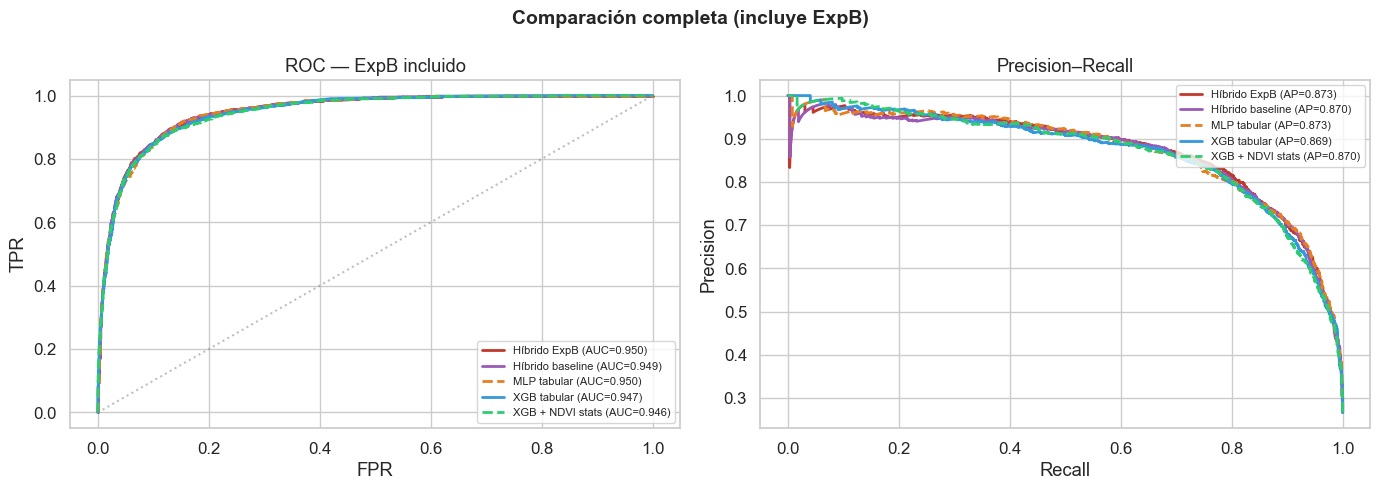

In [27]:
# --- Tabla + curvas: ExpB vs baselines (necesita §7 para XGB/MLP/baseline) ---
comp_thresholds = np.arange(0.1, 0.9, 0.01)


def _best_f1_all(y_true, y_score):
    return max(
        f1_score(y_true, (y_score >= t).astype(int), zero_division=0)
        for t in comp_thresholds
    )


def _row(name, y_score):
    return {
        'Modelo': name,
        'ROC AUC': roc_auc_score(y_test_arr, y_score),
        'Avg Precision': average_precision_score(y_test_arr, y_score),
        'Best F1': _best_f1_all(y_test_arr, y_score),
    }


rows_all = []
rows_all.append(_row('Híbrido ExpB (CNN+aux+NDVI norm)', proba_expb))

y_hyb = globals().get('y_pred_proba_hybrid')
if y_hyb is not None:
    rows_all.append(_row('Híbrido baseline (§6)', y_hyb))
else:
    print('Aviso: ejecutá §6 para incluir el híbrido baseline en la tabla.')

y_mlp = globals().get('y_pred_mlp_tab')
if y_mlp is not None:
    rows_all.append(_row('MLP tabular (03)', y_mlp))

y_xgb_b = globals().get('y_pred_xgb_base')
y_xgb_n = globals().get('y_pred_xgb_ndvi')
if y_xgb_b is not None and y_xgb_n is not None:
    rows_all.append(_row('XGBoost tabular', y_xgb_b))
    rows_all.append(_row('XGBoost + stats NDVI', y_xgb_n))
else:
    print('Aviso: ejecutá §7 para incluir XGBoost en la tabla.')

comparison_all = pd.DataFrame(rows_all)
print('=' * 72)
print('TEST 2025-2026 — ExpB vs demás modelos')
print('=' * 72)
display(comparison_all.round(4))

# Curvas ROC / PR
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
styles = [('Híbrido ExpB', proba_expb, '#c0392b', '-')]
if y_hyb is not None:
    styles.append(('Híbrido baseline', y_hyb, '#9b59b6', '-'))
if y_mlp is not None:
    styles.append(('MLP tabular', y_mlp, '#e67e22', '--'))
if y_xgb_b is not None and y_xgb_n is not None:
    styles.extend([
        ('XGB tabular', y_xgb_b, '#3498db', '-'),
        ('XGB + NDVI stats', y_xgb_n, '#2ecc71', '--'),
    ])

for name, probs, color, ls in styles:
    if probs is None:
        continue
    fpr_c, tpr_c, _ = roc_curve(y_test_arr, probs)
    axes[0].plot(
        fpr_c, tpr_c, linewidth=2, color=color, linestyle=ls,
        label=f"{name} (AUC={roc_auc_score(y_test_arr, probs):.3f})",
    )
axes[0].plot([0, 1], [0, 1], ':', color='gray', alpha=0.5)
axes[0].set_xlabel('FPR')
axes[0].set_ylabel('TPR')
axes[0].set_title('ROC — ExpB incluido')
axes[0].legend(fontsize=8, loc='lower right')

for name, probs, color, ls in styles:
    if probs is None:
        continue
    prec_c, rec_c, _ = precision_recall_curve(y_test_arr, probs)
    ap_v = average_precision_score(y_test_arr, probs)
    axes[1].plot(
        rec_c, prec_c, linewidth=2, color=color, linestyle=ls,
        label=f"{name} (AP={ap_v:.3f})",
    )
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision–Recall')
axes[1].legend(fontsize=8, loc='upper right')

plt.suptitle('Comparación completa (incluye ExpB)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
